# lorenz96ReportV4 - self-contained reproducible Project D notebook

This notebook is intentionally **self-contained** and V4 keeps the successful JUNO run outputs: it reconstructs the project source tree from cells inside the notebook, then regenerates the datasets, trains all models, evaluates autoregressive rollouts, computes chaos diagnostics, collects outputs, and builds the final report figures.

It does **not** require `lorenz96_project_final_reproducible_package.zip`.

Expected kernel on JUNO:

```text
Python (lorenz_ml)
```

Expected Python executable:

```text
/work/ext/st02/conda_envs/lorenz_ml/bin/python
```

## 0. Environment sanity check

Run this first. It confirms that the notebook kernel can see PyTorch and CUDA.

In [1]:
import sys
print(sys.executable)

try:
    import torch
    print('torch', torch.__version__)
    print('cuda', torch.cuda.is_available())
    if torch.cuda.is_available():
        print('gpu', torch.cuda.get_device_name(0))
except Exception as e:
    print('TORCH CHECK FAILED:', repr(e))
    raise

/work/ext/st02/conda_envs/lorenz_ml/bin/python
torch 2.0.1
cuda True
gpu NVIDIA A100-PCIE-40GB


## 1. Recreate the project source tree from the notebook

The next cells write every source file needed by the project. This is why the notebook alone is sufficient for reproduction.

In [2]:
%%bash
set -euo pipefail

rm -rf lorenz96_project_final_package
mkdir -p lorenz96_project_final_package/src
mkdir -p lorenz96_project_final_package/tools
mkdir -p lorenz96_project_final_package/notebooks

echo "Created clean source tree:"
find lorenz96_project_final_package -maxdepth 2 -type d -print

Created clean source tree:
lorenz96_project_final_package
lorenz96_project_final_package/tools
lorenz96_project_final_package/notebooks
lorenz96_project_final_package/src


### Write `requirements.txt`

In [3]:
%%writefile lorenz96_project_final_package/requirements.txt
numpy>=1.24
matplotlib>=3.7
torch>=2.0


Writing lorenz96_project_final_package/requirements.txt


### Write `README.md`

In [4]:
%%writefile lorenz96_project_final_package/README.md
# Lorenz Project D — Final 100k Reproducible Package

This is the ordered final package for the mini-project **ML Emulation of Chaotic Dynamical Systems**.

It contains the compact 4-script pipeline used to generate the final 100k results:

1. `01_generate_100k_data.py`
2. `02_train_100k_models.py`
3. `03_evaluate_100k_rollouts.py`
4. `04_chaos_100k_summary.py`

The package also includes the current completed JUNO run: final datasets, trained models, reports, and figures.

---

## Environment

Recommended environment already tested on JUNO:

```bash
python >= 3.10
numpy
matplotlib
torch with CUDA if available
```

Install minimal dependencies if needed:

```bash
pip install -r requirements.txt
```

On JUNO, activate the existing environment:

```bash
source /work/ext/st02/miniconda3/etc/profile.d/conda.sh
conda activate /work/ext/st02/conda_envs/lorenz_ml
```

---

## Final run order

Run from the project root:

```bash
cd lorenz96_project_final_package
python 01_generate_100k_data.py 2>&1 | tee reports/01_generate_100k_data.log
python 02_train_100k_models.py 2>&1 | tee reports/02_train_100k_models.log
python 03_evaluate_100k_rollouts.py 2>&1 | tee reports/03_evaluate_100k_rollouts.log
python 04_chaos_100k_summary.py 2>&1 | tee reports/04_chaos_100k_summary.log
```

The scripts create or update:

```text
data/l63_100k.npz
data/l96_100k.npz
models/*_100k.pt
reports/*.txt / *.csv / *.json
figures/*.png
```

---

## What each script does

### 01_generate_100k_data.py
Generates RK4 L63/L96 trajectories with:

```text
dt = 0.01
n_steps = 100000 after spin-up
spinup_steps = 5000
split = 70% train, 15% validation, 15% test
```

It saves both next-state and tendency supervised-learning targets.

### 02_train_100k_models.py
Trains all 8 final emulators:

```text
L63 MLP next-state
L63 MLP tendency
L63 CNN next-state
L63 CNN tendency
L96 MLP next-state
L96 MLP tendency
L96 CNN next-state
L96 CNN tendency
```

### 03_evaluate_100k_rollouts.py
Runs autoregressive rollouts for all 8 models, computes RMSE(t), prediction horizons, and power spectra for the best one-step-equivalent emulators.

### 04_chaos_100k_summary.py
Computes leading Lyapunov exponents, L63 FTLE windows, FTLE distribution/attractor-error figures, and final notebook-ready scientific summary.

---

## Collect one PC's results into a single ZIP

After a PC finishes the 4-script run, execute:

```bash
python tools/collect_final_results.py --run-id PC1
```

This creates:

```text
collected_runs/lorenz96_results_PC1.zip
```

Ask each team member / PC to send back one ZIP.

Suggested run IDs:

```text
PC1_yourname
PC2_teammate
PC3_teammate
PC4_teammate
```

---

## Compare results from 4 PCs

Place the collected ZIPs in `collected_runs/`, then run:

```bash
python tools/compare_collected_runs.py collected_runs/*.zip
```

This creates:

```text
comparison_outputs/combined_training_summary.csv
comparison_outputs/combined_rollout_summary.csv
comparison_outputs/combined_prediction_horizon.csv
comparison_outputs/combined_lyapunov_table.csv
comparison_outputs/combined_ftle_summary.csv
comparison_outputs/cross_run_comparison_summary.txt
comparison_outputs/cross_run_training_as_next_mse.png
comparison_outputs/cross_run_rollout_horizon.png
comparison_outputs/cross_run_lyapunov.png
```

Use these outputs in the final notebook to discuss reproducibility across 4 runs.

---

## Notebook preparation

The final notebook should be lightweight:

- explain the scientific question;
- load the final CSV/TXT summaries;
- display final figures;
- discuss negative and ambiguous results honestly;
- include the run order above;
- optionally include cross-PC comparison once the other 3 result ZIPs are collected.

Key notebook-ready files:

```text
reports/12_train_100k_models_summary_clean.txt
reports/13_rollout_100k_summary.txt
reports/13_prediction_horizon_100k.txt
reports/14_lyapunov_100k_table.txt
reports/14_ftle_l63_100k_summary.txt
reports/14_final_100k_scientific_summary.txt

figures/l63_100k_rollout_rmse_all.png
figures/l96_100k_rollout_rmse_all.png
figures/13_prediction_horizon_100k.png
figures/l63_100k_power_spectrum_best.png
figures/l96_100k_power_spectrum_best.png
figures/14_lyapunov_100k_bar.png
figures/14_ftle_l63_100k_hist.png
figures/14_ftle_l63_100k_scatter.png
figures/14_ftle_l63_100k_error_on_attractor.png
```


Writing lorenz96_project_final_package/README.md


### Write `README_FINAL_RUN_ORDER.md`

In [5]:
%%writefile lorenz96_project_final_package/README_FINAL_RUN_ORDER.md
# Lorenz Project D — Final 100k Reproducible Package

This is the ordered final package for the mini-project **ML Emulation of Chaotic Dynamical Systems**.

It contains the compact 4-script pipeline used to generate the final 100k results:

1. `01_generate_100k_data.py`
2. `02_train_100k_models.py`
3. `03_evaluate_100k_rollouts.py`
4. `04_chaos_100k_summary.py`

The package also includes the current completed JUNO run: final datasets, trained models, reports, and figures.

---

## Environment

Recommended environment already tested on JUNO:

```bash
python >= 3.10
numpy
matplotlib
torch with CUDA if available
```

Install minimal dependencies if needed:

```bash
pip install -r requirements.txt
```

On JUNO, activate the existing environment:

```bash
source /work/ext/st02/miniconda3/etc/profile.d/conda.sh
conda activate /work/ext/st02/conda_envs/lorenz_ml
```

---

## Final run order

Run from the project root:

```bash
cd lorenz96_project_final_package
python 01_generate_100k_data.py 2>&1 | tee reports/01_generate_100k_data.log
python 02_train_100k_models.py 2>&1 | tee reports/02_train_100k_models.log
python 03_evaluate_100k_rollouts.py 2>&1 | tee reports/03_evaluate_100k_rollouts.log
python 04_chaos_100k_summary.py 2>&1 | tee reports/04_chaos_100k_summary.log
```

The scripts create or update:

```text
data/l63_100k.npz
data/l96_100k.npz
models/*_100k.pt
reports/*.txt / *.csv / *.json
figures/*.png
```

---

## What each script does

### 01_generate_100k_data.py
Generates RK4 L63/L96 trajectories with:

```text
dt = 0.01
n_steps = 100000 after spin-up
spinup_steps = 5000
split = 70% train, 15% validation, 15% test
```

It saves both next-state and tendency supervised-learning targets.

### 02_train_100k_models.py
Trains all 8 final emulators:

```text
L63 MLP next-state
L63 MLP tendency
L63 CNN next-state
L63 CNN tendency
L96 MLP next-state
L96 MLP tendency
L96 CNN next-state
L96 CNN tendency
```

### 03_evaluate_100k_rollouts.py
Runs autoregressive rollouts for all 8 models, computes RMSE(t), prediction horizons, and power spectra for the best one-step-equivalent emulators.

### 04_chaos_100k_summary.py
Computes leading Lyapunov exponents, L63 FTLE windows, FTLE distribution/attractor-error figures, and final notebook-ready scientific summary.

---

## Collect one PC's results into a single ZIP

After a PC finishes the 4-script run, execute:

```bash
python tools/collect_final_results.py --run-id PC1
```

This creates:

```text
collected_runs/lorenz96_results_PC1.zip
```

Ask each team member / PC to send back one ZIP.

Suggested run IDs:

```text
PC1_yourname
PC2_teammate
PC3_teammate
PC4_teammate
```

---

## Compare results from 4 PCs

Place the collected ZIPs in `collected_runs/`, then run:

```bash
python tools/compare_collected_runs.py collected_runs/*.zip
```

This creates:

```text
comparison_outputs/combined_training_summary.csv
comparison_outputs/combined_rollout_summary.csv
comparison_outputs/combined_prediction_horizon.csv
comparison_outputs/combined_lyapunov_table.csv
comparison_outputs/combined_ftle_summary.csv
comparison_outputs/cross_run_comparison_summary.txt
comparison_outputs/cross_run_training_as_next_mse.png
comparison_outputs/cross_run_rollout_horizon.png
comparison_outputs/cross_run_lyapunov.png
```

Use these outputs in the final notebook to discuss reproducibility across 4 runs.

---

## Notebook preparation

The final notebook should be lightweight:

- explain the scientific question;
- load the final CSV/TXT summaries;
- display final figures;
- discuss negative and ambiguous results honestly;
- include the run order above;
- optionally include cross-PC comparison once the other 3 result ZIPs are collected.

Key notebook-ready files:

```text
reports/12_train_100k_models_summary_clean.txt
reports/13_rollout_100k_summary.txt
reports/13_prediction_horizon_100k.txt
reports/14_lyapunov_100k_table.txt
reports/14_ftle_l63_100k_summary.txt
reports/14_final_100k_scientific_summary.txt

figures/l63_100k_rollout_rmse_all.png
figures/l96_100k_rollout_rmse_all.png
figures/13_prediction_horizon_100k.png
figures/l63_100k_power_spectrum_best.png
figures/l96_100k_power_spectrum_best.png
figures/14_lyapunov_100k_bar.png
figures/14_ftle_l63_100k_hist.png
figures/14_ftle_l63_100k_scatter.png
figures/14_ftle_l63_100k_error_on_attractor.png
```


Writing lorenz96_project_final_package/README_FINAL_RUN_ORDER.md


### Write `PACKAGE_MANIFEST.json`

In [6]:
%%writefile lorenz96_project_final_package/PACKAGE_MANIFEST.json
{
  "created_at": "2026-06-10T10:25:57",
  "source_backup": "lorenz96_project_backup_100k_complete_20260610_122112.tar.gz",
  "files": [
    {
      "path": "01_generate_100k_data.py",
      "size_bytes": 7297,
      "sha256": "1e59239adea103ef6ddd603328ec07cc074f45bb59f736cec69bdc17bd3142bb"
    },
    {
      "path": "02_train_100k_models.py",
      "size_bytes": 14509,
      "sha256": "2250cc5969a24293e17a6c4667935c705d590df7d44c3030767a12a29c31ab69"
    },
    {
      "path": "03_evaluate_100k_rollouts.py",
      "size_bytes": 19776,
      "sha256": "18e7cf29dd4179e5d2a83304be82b7ac0e0df46f0a4999e10985119fca22ce03"
    },
    {
      "path": "04_chaos_100k_summary.py",
      "size_bytes": 24391,
      "sha256": "33f09b2dab878d78722ec6d8a0281c96490c56525904c608407e273ba578b7dc"
    },
    {
      "path": "README.md",
      "size_bytes": 4336,
      "sha256": "172c2d757f93dffc053848b4ad0085ff7df9c62dbf695aa030307c7d5967533c"
    },
    {
      "path": "README_FINAL_RUN_ORDER.md",
      "size_bytes": 4336,
      "sha256": "172c2d757f93dffc053848b4ad0085ff7df9c62dbf695aa030307c7d5967533c"
    },
    {
      "path": "data/l63_100k.npz",
      "size_bytes": 6678395,
      "sha256": "191ac2832abacda1408c715b9d3090b137ec4396ff4da210b804d11bb0f5c295"
    },
    {
      "path": "data/l96_100k.npz",
      "size_bytes": 88447260,
      "sha256": "ea099b38580bc3d71096a30ed372ce988b04a45625eaeb26b5da78a9142cf3ae"
    },
    {
      "path": "figures/13_prediction_horizon_100k.png",
      "size_bytes": 90974,
      "sha256": "9e152f9debed5d120597c214a17917a43bde197267c9307491a83aa45a20e4e2"
    },
    {
      "path": "figures/14_ftle_l63_100k_error_on_attractor.png",
      "size_bytes": 113295,
      "sha256": "b211e4a4a0a9bdcbcfe98b60be0cb19a70bb81e7fd781d2ca4ac39c561fceece"
    },
    {
      "path": "figures/14_ftle_l63_100k_hist.png",
      "size_bytes": 47462,
      "sha256": "ac4a3249346a5d251e5a932bb87212d6c4bab1aa788e92431393bb3541a73359"
    },
    {
      "path": "figures/14_ftle_l63_100k_scatter.png",
      "size_bytes": 158384,
      "sha256": "bf8c5aa0f682055bc4cde7d80fa49af3fb3ade6e935aeff97341c27bc9b7d632"
    },
    {
      "path": "figures/14_lyapunov_100k_bar.png",
      "size_bytes": 128256,
      "sha256": "2abb1574022ae7af93eb2e6b29590455d3a950ba1789795be2e5ef60edd930b6"
    },
    {
      "path": "figures/l63_100k_best_rollout_xyz.png",
      "size_bytes": 508420,
      "sha256": "8c260daa2d83689bc9187e62d9d4ff8559e1ef6d274308e9b4b6e5c870a0e1d7"
    },
    {
      "path": "figures/l63_100k_power_spectrum_best.png",
      "size_bytes": 154440,
      "sha256": "fa8c3f1ca94270c20b7d67bb6ea61f261364aadd67bd32e580cd965495fa3300"
    },
    {
      "path": "figures/l63_100k_rollout_rmse_all.png",
      "size_bytes": 160123,
      "sha256": "f6bf7fe0d0f123217376b1a0e93ee2b729fdcd3adba1b121b3c9e4d189b1b896"
    },
    {
      "path": "figures/l63_cnn_next_100k_loss.png",
      "size_bytes": 102205,
      "sha256": "75022734cd802d5a12038e30f1b8271ae56855c37e2b51480dfce8b7c366eca1"
    },
    {
      "path": "figures/l63_cnn_tendency_100k_loss.png",
      "size_bytes": 103365,
      "sha256": "533c749064fe5c2dd9890081f5e2b44128c5b09a3e60cd6ae8fb141bb7cbc60b"
    },
    {
      "path": "figures/l63_mlp_next_100k_loss.png",
      "size_bytes": 123263,
      "sha256": "e581e0ae2e03f12998dabf1937fd79071ceaf349989a8e48803c534f339c8a0d"
    },
    {
      "path": "figures/l63_mlp_tendency_100k_loss.png",
      "size_bytes": 113968,
      "sha256": "346acc593c447704363438104383a2c542e02434278389cb0aeb2b3d28fe7fe9"
    },
    {
      "path": "figures/l96_100k_best_rollout_state0.png",
      "size_bytes": 326333,
      "sha256": "6eff039a513afca099314b60395993b585920824751f292d8b12d296c5fd4928"
    },
    {
      "path": "figures/l96_100k_power_spectrum_best.png",
      "size_bytes": 151810,
      "sha256": "bb157f7c6bd9e6a4c24e7a72ca323b2a60ab0f60330ce2d1922cbd4a549c405c"
    },
    {
      "path": "figures/l96_100k_rollout_rmse_all.png",
      "size_bytes": 89322,
      "sha256": "aeb398bd95f77652af2accdb44002a869dc205c982bf9d19f636a01bc659199a"
    },
    {
      "path": "figures/l96_cnn_next_100k_loss.png",
      "size_bytes": 121821,
      "sha256": "0994a5fc9cf6900fbd86394f8fca48e825d435d5d297d499034056593797651c"
    },
    {
      "path": "figures/l96_cnn_tendency_100k_loss.png",
      "size_bytes": 96670,
      "sha256": "57ac5d1e84a33da397ed63d9d68deff182e8f48eae7052eba522ae5efd60bdc7"
    },
    {
      "path": "figures/l96_mlp_next_100k_loss.png",
      "size_bytes": 94423,
      "sha256": "4851668a1b893441243173b263dbf8542f9e5e94510dd56fbfa14355994a0fac"
    },
    {
      "path": "figures/l96_mlp_tendency_100k_loss.png",
      "size_bytes": 71628,
      "sha256": "aeffdf89429a2a9c6efd33ce2851207e558acce8c4e312f09ace7c3f64e9359d"
    },
    {
      "path": "models/l63_cnn_next_100k.pt",
      "size_bytes": 103539,
      "sha256": "272254f40c54265699e7d79a9f49a2e4e20d7703bc9d5c5b1fda444a9e73cdd1"
    },
    {
      "path": "models/l63_cnn_tendency_100k.pt",
      "size_bytes": 103643,
      "sha256": "869e9fee5a91bd2c24c74e6f748f18b06ef32f557efb40c93c912065ef4542d3"
    },
    {
      "path": "models/l63_mlp_next_100k.pt",
      "size_bytes": 536947,
      "sha256": "5383d3baf6e0ba02587c09f6c12ee96c0f900dacaccd59926fc7b38f98a0bbd9"
    },
    {
      "path": "models/l63_mlp_tendency_100k.pt",
      "size_bytes": 536987,
      "sha256": "51dc402631f3ccb685fde0716053de27107996ada9e6118118e54a6bd7238de6"
    },
    {
      "path": "models/l96_cnn_next_100k.pt",
      "size_bytes": 169587,
      "sha256": "37c205c4b4d37453fbc7d81c6ba7d075173c9a18616ac8df30bf263b148ec907"
    },
    {
      "path": "models/l96_cnn_tendency_100k.pt",
      "size_bytes": 169691,
      "sha256": "4fc880e2027995c29f8c4aee3b6bcaafb4c2853b716ed8bc436f504d85dd1f56"
    },
    {
      "path": "models/l96_mlp_next_100k.pt",
      "size_bytes": 612851,
      "sha256": "a995020f787d2be720a4dd0d17deac044151c799db313159c3483eda5c673357"
    },
    {
      "path": "models/l96_mlp_tendency_100k.pt",
      "size_bytes": 612891,
      "sha256": "8b29004b6206350802c505fe2e947ccb9ec1d30c20334c9ef09077b0c4982ef6"
    },
    {
      "path": "notebooks/previous_project_d_template.ipynb",
      "size_bytes": 967624,
      "sha256": "ab52bd3e76beca5f75b02348508a1cd141f28b8de6c3b4ab86c1672641da0175"
    },
    {
      "path": "reports/11_generate_100k_data.log",
      "size_bytes": 4737,
      "sha256": "b6cff6941bd2256b0134ce6b2b29bf2a86b227caf47cd8a85ab625f95815c2f3"
    },
    {
      "path": "reports/11_generate_100k_data_summary.json",
      "size_bytes": 750,
      "sha256": "b0c9cd41e1a0e81c0d147c373d97eca51d139e1aff7a0cfe9d63b4684e4eba95"
    },
    {
      "path": "reports/11_generate_100k_data_summary.txt",
      "size_bytes": 601,
      "sha256": "4c3751b44ec5cb902adff14b7a91b61c0fcaf02471d22710baf34412401d7915"
    },
    {
      "path": "reports/12_train_100k_models.log",
      "size_bytes": 18936,
      "sha256": "67e99e29041525f35a2c8cd2359c905dfd809f6054e40b01e6230addaeaf5518"
    },
    {
      "path": "reports/12_train_100k_models_summary.csv",
      "size_bytes": 3091,
      "sha256": "0c83854051c46b2f33e76d906824d6b40ab1e2d045f355eb04e6ca33de60653c"
    },
    {
      "path": "reports/12_train_100k_models_summary.json",
      "size_bytes": 6743,
      "sha256": "042f01b1e8bfbcb6989d89d788fb5ef6c56b0da8eab2aed269b2afa678d2f629"
    },
    {
      "path": "reports/12_train_100k_models_summary.txt",
      "size_bytes": 691,
      "sha256": "95397a67058e86748d4a8da980266ae6ed084ffc8c99650435e42992d5c0d8e5"
    },
    {
      "path": "reports/12_train_100k_models_summary_clean.csv",
      "size_bytes": 2378,
      "sha256": "b35ff439fb6f4ba8df391b26716f3cd896732f425674a6b62c13b1a491382092"
    },
    {
      "path": "reports/12_train_100k_models_summary_clean.json",
      "size_bytes": 4654,
      "sha256": "fd6030309cf019cb6734eea0f75d5eee752eadd2556c84ab9219b1c3140734c7"
    },
    {
      "path": "reports/12_train_100k_models_summary_clean.txt",
      "size_bytes": 1643,
      "sha256": "375d9c456dba0bf852e76dc81546e2dd8196438a5cac2ac008537f6847a495dd"
    },
    {
      "path": "reports/13_evaluate_100k_rollouts.log",
      "size_bytes": 6978,
      "sha256": "50c65fb882c3a39ff032304630b95e31a86bc5d293238f873079c3f71e337270"
    },
    {
      "path": "reports/13_prediction_horizon_100k.csv",
      "size_bytes": 852,
      "sha256": "0968b2f9913cf3c906c99d86199273cc22149201d174b1999d249393239f7b4a"
    },
    {
      "path": "reports/13_prediction_horizon_100k.txt",
      "size_bytes": 881,
      "sha256": "517953e07b61c6b5e9b0aca3035d72cb3a2a1732e9cfade06515eb28aad0cda0"
    },
    {
      "path": "reports/13_rollout_100k_summary.csv",
      "size_bytes": 1790,
      "sha256": "86a85fd5368b7248c0fd00c6bc34b447db0e0f1c0995bda2657ecd629b299bd0"
    },
    {
      "path": "reports/13_rollout_100k_summary.json",
      "size_bytes": 13448,
      "sha256": "81c77feb304d3cca9c67c663318a077cd3ecdb16a0ee2011fa132d43b7ad9f3d"
    },
    {
      "path": "reports/13_rollout_100k_summary.txt",
      "size_bytes": 1921,
      "sha256": "10704226e5e761a8ad6fb30f90aa7f282c4c490fd3599d3f3b06e40120876e0c"
    },
    {
      "path": "reports/14_chaos_100k_summary.log",
      "size_bytes": 10398,
      "sha256": "ff3b5f3cbfaacbb3da78202db6693e500a0572d393798d024d9c061e3d3c1367"
    },
    {
      "path": "reports/14_final_100k_scientific_summary.json",
      "size_bytes": 5111,
      "sha256": "129e6aa0229f67f152f26b39ba18f657ca1ac2dc7210eb1cb4bc2fda20cdfeb4"
    },
    {
      "path": "reports/14_final_100k_scientific_summary.txt",
      "size_bytes": 7949,
      "sha256": "9d509db5a54ffbe1d18bc00ed30952f9f22034e97573db0530601380baa28d3c"
    },
    {
      "path": "reports/14_ftle_l63_100k_summary.csv",
      "size_bytes": 524,
      "sha256": "ab53ade114df888af5768ea6a7f415e48493307e400906710f15528d44289302"
    },
    {
      "path": "reports/14_ftle_l63_100k_summary.txt",
      "size_bytes": 654,
      "sha256": "2613b788ce5a7bd8fd65da5cc292310ba7d66e77612e1f1099b155b0eeca860d"
    },
    {
      "path": "reports/14_ftle_l63_100k_values.csv",
      "size_bytes": 21723,
      "sha256": "4fc434d5137cbf198fc8b99b27ed122fc16ee2fcf1d54541482ab712983039a5"
    },
    {
      "path": "reports/14_lyapunov_100k_running.csv",
      "size_bytes": 3344,
      "sha256": "4ffae3fb46d584070ef9e2860670307492d1162cc4063246a82eb3148cacc6bc"
    },
    {
      "path": "reports/14_lyapunov_100k_table.csv",
      "size_bytes": 1358,
      "sha256": "9b56c9f38572584ca940b4dcdedbb9d33a69fb745700c8c01e0e57dbea4e2257"
    },
    {
      "path": "reports/14_lyapunov_100k_table.txt",
      "size_bytes": 813,
      "sha256": "fd479ca5da9d09eb6849e71533e0744b68f4aef7be292395d5c7190a8344aa69"
    },
    {
      "path": "reports/l63_100k_rollout_rmse_timeseries.csv",
      "size_bytes": 489655,
      "sha256": "0e1e22fe26f96d64b6acaa747c13cebd48867bde8ec9f922921f0f164de81cec"
    },
    {
      "path": "reports/l63_cnn_next_100k_metrics.txt",
      "size_bytes": 496,
      "sha256": "e0217c6c2d8fc5307b58e44328088614cabc76f4658e42d523467be2fb65b041"
    },
    {
      "path": "reports/l63_cnn_tendency_100k_metrics.txt",
      "size_bytes": 578,
      "sha256": "36cf9a42d4f7e886c6d1e7e4e3a386b4b56885c36b74d3b46d56ce58e6c407f8"
    },
    {
      "path": "reports/l63_mlp_next_100k_metrics.txt",
      "size_bytes": 497,
      "sha256": "a066d2bb9d10aac00d69a804c7adec2e4d7021d7c1c84052d79efc980dc15750"
    },
    {
      "path": "reports/l63_mlp_tendency_100k_metrics.txt",
      "size_bytes": 579,
      "sha256": "b3a38ca8de2417b4dde5469c46abaa2f12ce17d26ed80ac20b8fbc1cf79a1b23"
    },
    {
      "path": "reports/l96_100k_rollout_rmse_timeseries.csv",
      "size_bytes": 466279,
      "sha256": "97c96e5f8c60e8bfbf32af3e2ea65d50066058c34a0e20adb50b27030bf647fa"
    },
    {
      "path": "reports/l96_cnn_next_100k_metrics.txt",
      "size_bytes": 496,
      "sha256": "a053ae95d5a1fcf9a3c377dd43dd3412863ad5674ee700fb16c3c9c2e8d3cfef"
    },
    {
      "path": "reports/l96_cnn_tendency_100k_metrics.txt",
      "size_bytes": 578,
      "sha256": "693d257dee3e233df46efc595b273d87299e65c6dc339a55a8befd8bd0e7b430"
    },
    {
      "path": "reports/l96_mlp_next_100k_metrics.txt",
      "size_bytes": 497,
      "sha256": "8b055dc49979dd6b5c3a91ff92c9b009d69f291f5f4ccfda85639ee37e0e8873"
    },
    {
      "path": "reports/l96_mlp_tendency_100k_metrics.txt",
      "size_bytes": 579,
      "sha256": "b4fe34709fe49e34cf81a25f6a2ea03a51aac480a416e818283b61fd222dcb2b"
    },
    {
      "path": "requirements.txt",
      "size_bytes": 39,
      "sha256": "f13f1f379ab6ef86c301ed46526ee7ea37f4bdbc181eb56e19833fe763e4fdd3"
    },
    {
      "path": "run_final_pipeline.sh",
      "size_bytes": 441,
      "sha256": "d6e5c6d74a6ef19f97d43991daf7f08932dd163ad24df229a7f7802adcfc6921"
    },
    {
      "path": "src/__pycache__/lorenz_systems.cpython-311.pyc",
      "size_bytes": 9269,
      "sha256": "3cb3836b7c9bf5024c74283d654af36170acd5637240f899ee7c1a6dab85f554"
    },
    {
      "path": "src/__pycache__/ml_models.cpython-311.pyc",
      "size_bytes": 7556,
      "sha256": "dce2ec615cbae973f941030b2930af16b77504edf5898635d108242f8c9a03c0"
    },
    {
      "path": "src/lorenz_systems.py",
      "size_bytes": 7974,
      "sha256": "850e412ab204184e7896c86df78fb1e290f5241c7ac8df8f67d0fcb8e0990938"
    },
    {
      "path": "src/ml_models.py",
      "size_bytes": 5178,
      "sha256": "868947135b3c106a249094bbf5425df6eaa2bfd2c2ba99d16417ed55519b2309"
    },
    {
      "path": "tools/collect_final_results.py",
      "size_bytes": 4678,
      "sha256": "3b4912ba01a1ebb093320ff8684347b359f2dc9853508e75eb5b4ac66868c516"
    },
    {
      "path": "tools/compare_collected_runs.py",
      "size_bytes": 8730,
      "sha256": "9585978224a05f58e775c2a8f5ca509a029b6ddebaf506879a598f5614ea54e9"
    }
  ]
}

Writing lorenz96_project_final_package/PACKAGE_MANIFEST.json


### Write `run_final_pipeline.sh`

In [7]:
%%writefile lorenz96_project_final_package/run_final_pipeline.sh
#!/usr/bin/env bash
set -euo pipefail
mkdir -p reports figures models data
python 01_generate_100k_data.py 2>&1 | tee reports/01_generate_100k_data.log
python 02_train_100k_models.py 2>&1 | tee reports/02_train_100k_models.log
python 03_evaluate_100k_rollouts.py 2>&1 | tee reports/03_evaluate_100k_rollouts.log
python 04_chaos_100k_summary.py 2>&1 | tee reports/04_chaos_100k_summary.log
python tools/collect_final_results.py --run-id auto


Writing lorenz96_project_final_package/run_final_pipeline.sh


### Write `src/lorenz_systems.py`

In [8]:
%%writefile lorenz96_project_final_package/src/lorenz_systems.py
"""
Utilities for simulating Lorenz-63 and Lorenz-96 systems.

This module contains:
- right-hand-side functions for Lorenz-63 and Lorenz-96;
- a generic RK4 time-stepping routine;
- trajectory generation utilities;
- train/validation/test splitting;
- supervised learning pair construction.

The goal is to keep the dynamical-system code separate from the ML code,
so that the same trajectories can be reused by the MLP, CNN, rollout,
Lyapunov, and FTLE parts of the project.
"""

import numpy as np


def lorenz63_rhs(x, sigma=10.0, rho=28.0, beta=8.0 / 3.0):
    """
    Compute the Lorenz-63 right-hand side.

    The Lorenz-63 system is a 3-dimensional chaotic system:

        dx/dt = sigma * (y - x)
        dy/dt = x * (rho - z) - y
        dz/dt = x * y - beta * z

    Standard chaotic parameters are:
        sigma = 10
        rho   = 28
        beta  = 8/3

    Parameters
    ----------
    x : array-like, shape (3,)
        Current state vector [x, y, z].
    sigma : float
        Prandtl-number-like parameter.
    rho : float
        Rayleigh-number-like forcing parameter.
    beta : float
        Geometric parameter.

    Returns
    -------
    dxdt : ndarray, shape (3,)
        Time derivative of the current state.
    """
    x = np.asarray(x, dtype=np.float64)

    # Allocate output with the same shape as the input state.
    dx = np.empty_like(x)

    # Unpack the three state variables for readability.
    x0 = x[0]
    y0 = x[1]
    z0 = x[2]

    # Lorenz-63 equations.
    dx[0] = sigma * (y0 - x0)
    dx[1] = x0 * (rho - z0) - y0
    dx[2] = x0 * y0 - beta * z0

    return dx


def lorenz96_rhs(x, F=8.0):
    """
    Compute the Lorenz-96 right-hand side.

    The Lorenz-96 system is an N-dimensional chaotic model with periodic
    boundary conditions. It is often used as a simplified model of
    large-scale atmospheric dynamics.

    Equation:

        dX_k/dt = (X_{k+1} - X_{k-2}) * X_{k-1} - X_k + F

    where the indices are cyclic, so for N variables:
        X_{-1} = X_{N-1}
        X_N    = X_0

    Parameters
    ----------
    x : array-like, shape (N,)
        Current Lorenz-96 state.
    F : float
        Constant forcing. The project uses F = 8.

    Returns
    -------
    dxdt : ndarray, shape (N,)
        Time derivative of the current state.
    """
    x = np.asarray(x, dtype=np.float64)

    # np.roll implements cyclic indexing:
    # np.roll(x, -1) gives X_{k+1}
    # np.roll(x,  1) gives X_{k-1}
    # np.roll(x,  2) gives X_{k-2}
    x_plus_1 = np.roll(x, -1)
    x_minus_1 = np.roll(x, 1)
    x_minus_2 = np.roll(x, 2)

    # Lorenz-96 equation with cyclic boundary conditions.
    dx = (x_plus_1 - x_minus_2) * x_minus_1 - x + F

    return dx


def rk4_step(rhs, x, dt, **rhs_kwargs):
    """
    Advance one time step using the classical fourth-order Runge-Kutta method.

    RK4 is used here because the project asks for reference trajectories
    generated with RK4. It gives a stable and accurate reference integration
    for small time steps such as dt = 0.01.

    Parameters
    ----------
    rhs : callable
        Function that computes dx/dt from the current state.
    x : array-like
        Current state.
    dt : float
        Time step.
    rhs_kwargs : dict
        Additional keyword arguments passed to the RHS function,
        for example F=8.0 for Lorenz-96.

    Returns
    -------
    x_next : ndarray
        State after one RK4 time step.
    """
    x = np.asarray(x, dtype=np.float64)

    # Four RK4 slope evaluations.
    k1 = rhs(x, **rhs_kwargs)
    k2 = rhs(x + 0.5 * dt * k1, **rhs_kwargs)
    k3 = rhs(x + 0.5 * dt * k2, **rhs_kwargs)
    k4 = rhs(x + dt * k3, **rhs_kwargs)

    # Weighted average of the four slopes.
    x_next = x + (dt / 6.0) * (k1 + 2.0 * k2 + 2.0 * k3 + k4)

    return x_next


def integrate(rhs, x0, dt, n_steps, spinup=0, sample_every=1, **rhs_kwargs):
    """
    Integrate a dynamical system using RK4 and return a saved trajectory.

    The function first runs a spin-up phase and discards those states.
    This is useful for chaotic systems because we usually want the saved
    trajectory to lie on the attractor rather than depend strongly on the
    arbitrary initial condition.

    Parameters
    ----------
    rhs : callable
        Right-hand-side function, such as lorenz63_rhs or lorenz96_rhs.
    x0 : array-like
        Initial condition.
    dt : float
        RK4 time step.
    n_steps : int
        Number of states to save after spin-up.
    spinup : int
        Number of RK4 steps to discard before saving.
    sample_every : int
        Save one state every sample_every RK4 steps.
        For example, sample_every=10 saves every 10th state.
    rhs_kwargs : dict
        Extra parameters passed to the RHS function.

    Returns
    -------
    trajectory : ndarray, shape (n_steps, state_dimension)
        Saved trajectory after spin-up.
    """
    x = np.asarray(x0, dtype=np.float64).copy()

    # Spin-up phase: advance the system but do not store states.
    for _ in range(spinup):
        x = rk4_step(rhs, x, dt, **rhs_kwargs)

    saved = []

    # If sample_every > 1, we perform more RK4 steps than saved samples.
    total_steps = n_steps * sample_every

    for step in range(total_steps):
        x = rk4_step(rhs, x, dt, **rhs_kwargs)

        # Store only every sample_every-th state.
        if (step + 1) % sample_every == 0:
            saved.append(x.copy())

    return np.asarray(saved)


def split_train_val_test(traj, train_frac=0.70, val_frac=0.15):
    """
    Split a trajectory into non-overlapping train, validation, and test windows.

    This follows the project requirement that train, validation, and test
    periods must not overlap. Because this is time-series data, we keep
    the chronological order instead of randomly shuffling the samples.

    Parameters
    ----------
    traj : ndarray, shape (time, state_dimension)
        Full trajectory.
    train_frac : float
        Fraction of trajectory used for training.
    val_frac : float
        Fraction of trajectory used for validation.
        The remaining fraction is used for testing.

    Returns
    -------
    train : ndarray
        First part of the trajectory.
    val : ndarray
        Middle part of the trajectory.
    test : ndarray
        Final part of the trajectory.
    """
    n = len(traj)

    n_train = int(n * train_frac)
    n_val = int(n * val_frac)

    train = traj[:n_train]
    val = traj[n_train:n_train + n_val]
    test = traj[n_train + n_val:]

    return train, val, test


def make_supervised_pairs(traj, mode="next_state", dt=0.01):
    """
    Convert a trajectory into one-step supervised learning pairs.

    This supports the two prediction targets required by the project:

    1. next_state:
        input  = x_t
        target = x_{t+1}

    2. tendency:
        input  = x_t
        target = (x_{t+1} - x_t) / dt

    A model trained in next_state mode directly predicts the next state.
    A model trained in tendency mode predicts the time derivative or finite
    difference tendency, which can later be converted into a next-step update.

    Parameters
    ----------
    traj : ndarray, shape (time, state_dimension)
        Input trajectory.
    mode : {"next_state", "tendency"}
        Type of supervised target to construct.
    dt : float
        Time step used for tendency targets.

    Returns
    -------
    x : ndarray, shape (time - 1, state_dimension)
        Input states.
    y : ndarray, shape (time - 1, state_dimension)
        Targets.
    """
    # Inputs are all states except the final one.
    x = traj[:-1]

    if mode == "next_state":
        # Target is the following state.
        y = traj[1:]

    elif mode == "tendency":
        # Target is a finite-difference approximation of dx/dt.
        y = (traj[1:] - traj[:-1]) / dt

    else:
        raise ValueError("mode must be 'next_state' or 'tendency'")

    return x, y


Writing lorenz96_project_final_package/src/lorenz_systems.py


### Write `src/ml_models.py`

In [9]:
%%writefile lorenz96_project_final_package/src/ml_models.py
"""
Neural-network models for Lorenz emulation.

This module contains two basic emulator architectures:

1. MLPEmulator
   - Fully connected neural network.
   - Can be used for both Lorenz-63 and Lorenz-96.
   - Treats the full state vector as a flat input.

2. PeriodicCNN1DEmulator
   - 1-D convolutional neural network with periodic padding.
   - Mainly useful for Lorenz-96 because L96 has a cyclic spatial structure.
   - Uses the same convolutional filters at every spatial location.

Both models can be trained either to predict:
- the next state x_{t+1};
- or the tendency (x_{t+1} - x_t) / dt.
"""

import torch
import torch.nn as nn
import torch.nn.functional as F


class MLPEmulator(nn.Module):
    """
    Fully connected emulator for dynamical-system states.

    Parameters
    ----------
    input_dim : int
        Dimension of the input state.
        For L63, input_dim = 3.
        For L96, input_dim = 40.
    output_dim : int
        Dimension of the output.
        Usually same as input_dim.
    hidden_dim : int
        Number of units in each hidden layer.
    n_hidden_layers : int
        Number of hidden layers.
    activation : callable
        PyTorch activation class, for example nn.ReLU.

    Notes
    -----
    This model has no explicit knowledge of spatial structure.
    For L96, it sees the 40 variables as a flat vector.
    """

    def __init__(
        self,
        input_dim,
        output_dim,
        hidden_dim=256,
        n_hidden_layers=3,
        activation=nn.ReLU,
    ):
        super().__init__()

        layers = []

        # First layer maps from state dimension to hidden dimension.
        layers.append(nn.Linear(input_dim, hidden_dim))
        layers.append(activation())

        # Middle hidden layers.
        for _ in range(n_hidden_layers - 1):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(activation())

        # Final layer maps back to the desired output dimension.
        layers.append(nn.Linear(hidden_dim, output_dim))

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        """
        Forward pass.

        x shape:
            (batch, state_dim)

        output shape:
            (batch, output_dim)
        """
        return self.net(x)


class PeriodicCNN1DEmulator(nn.Module):
    """
    1-D CNN emulator with periodic padding.

    This model is designed for Lorenz-96.

    Lorenz-96 variables live on a cyclic ring:
        X_0, X_1, ..., X_{N-1}, then back to X_0.

    Standard zero padding would create artificial boundaries.
    Periodic padding avoids this by wrapping the state around before
    applying convolutions.

    Input shape:
        (batch, state_dim)

    Internally converted to:
        (batch, channels=1, state_dim)

    Output shape:
        (batch, state_dim)
    """

    def __init__(
        self,
        state_dim=40,
        hidden_channels=64,
        kernel_size=5,
        n_layers=3,
    ):
        super().__init__()

        if kernel_size % 2 == 0:
            raise ValueError("kernel_size should be odd for symmetric padding")

        self.state_dim = state_dim
        self.kernel_size = kernel_size
        self.pad = kernel_size // 2

        layers = []

        # First convolution maps 1 input channel to hidden channels.
        layers.append(nn.Conv1d(1, hidden_channels, kernel_size))
        layers.append(nn.ReLU())

        # Middle convolutional layers.
        for _ in range(n_layers - 1):
            layers.append(nn.Conv1d(hidden_channels, hidden_channels, kernel_size))
            layers.append(nn.ReLU())

        # Final 1x1 convolution maps hidden channels back to 1 output channel.
        layers.append(nn.Conv1d(hidden_channels, 1, kernel_size=1))

        self.layers = nn.ModuleList(layers)

    def _periodic_pad(self, x):
        """
        Apply periodic padding along the spatial dimension.

        Input shape:
            (batch, channels, state_dim)

        Output shape:
            (batch, channels, state_dim + 2 * pad)
        """
        if self.pad == 0:
            return x

        return F.pad(x, (self.pad, self.pad), mode="circular")

    def forward(self, x):
        """
        Forward pass.

        Input:
            x shape = (batch, state_dim)

        Output:
            y shape = (batch, state_dim)
        """

        # Add channel dimension for Conv1d.
        x = x.unsqueeze(1)

        # Apply all layers manually so we can use periodic padding before
        # every convolution with kernel_size > 1.
        for layer in self.layers:
            if isinstance(layer, nn.Conv1d) and layer.kernel_size[0] > 1:
                x = self._periodic_pad(x)

            x = layer(x)

        # Remove channel dimension.
        x = x.squeeze(1)

        return x


def count_parameters(model):
    """
    Count the number of trainable parameters in a PyTorch model.

    This is useful for the project table comparing:
    - model complexity;
    - offline error;
    - online/rollout error;
    - stability;
    - Lyapunov estimates.
    """
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


Writing lorenz96_project_final_package/src/ml_models.py


### Write `tools/collect_final_results.py`

In [10]:
%%writefile lorenz96_project_final_package/tools/collect_final_results.py
# tools/collect_final_results.py
# Collect final Lorenz project outputs into one portable ZIP per PC/run.

from pathlib import Path
import argparse
import datetime as _dt
import hashlib
import json
import os
import platform
import socket
import sys
import zipfile

PROJECT_ROOT = Path(__file__).resolve().parents[1]


def sha256_file(path, chunk_size=1024 * 1024):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(chunk_size), b""):
            h.update(chunk)
    return h.hexdigest()


def safe_run_id(run_id):
    keep = []
    for ch in run_id:
        if ch.isalnum() or ch in "._-":
            keep.append(ch)
        else:
            keep.append("_")
    return "".join(keep).strip("_") or "run"


def get_env_info():
    info = {
        "timestamp": _dt.datetime.now().isoformat(timespec="seconds"),
        "hostname": socket.gethostname(),
        "platform": platform.platform(),
        "python": sys.version.replace("\n", " "),
        "project_root": str(PROJECT_ROOT),
    }
    try:
        import numpy as np
        info["numpy"] = np.__version__
    except Exception as exc:
        info["numpy_error"] = str(exc)
    try:
        import torch
        info["torch"] = torch.__version__
        info["cuda_available"] = bool(torch.cuda.is_available())
        if torch.cuda.is_available():
            info["gpu"] = torch.cuda.get_device_name(0)
    except Exception as exc:
        info["torch_error"] = str(exc)
    return info


def collect_files(include_models=False, include_data_hashes=True):
    files = []

    patterns = [
        "README*.md",
        "requirements.txt",
        "01_generate_100k_data.py",
        "02_train_100k_models.py",
        "03_evaluate_100k_rollouts.py",
        "04_chaos_100k_summary.py",
        "src/*.py",
        "reports/11_*",
        "reports/12_*",
        "reports/13_*",
        "reports/14_*",
        "reports/l63_*_100k_metrics.txt",
        "reports/l96_*_100k_metrics.txt",
        "reports/l63_100k_rollout_rmse_timeseries.csv",
        "reports/l96_100k_rollout_rmse_timeseries.csv",
        "figures/*100k*.png",
        "figures/13_prediction_horizon_100k.png",
        "figures/14_*.png",
    ]

    for pat in patterns:
        files.extend(PROJECT_ROOT.glob(pat))

    if include_models:
        files.extend((PROJECT_ROOT / "models").glob("*_100k.pt"))

    # Deduplicate and keep only files.
    uniq = []
    seen = set()
    for p in files:
        if p.is_file() and p not in seen:
            uniq.append(p)
            seen.add(p)

    manifest_files = []
    for p in sorted(uniq):
        rel = str(p.relative_to(PROJECT_ROOT))
        manifest_files.append({
            "path": rel,
            "size_bytes": p.stat().st_size,
            "sha256": sha256_file(p),
        })

    data_hashes = []
    if include_data_hashes:
        for p in sorted((PROJECT_ROOT / "data").glob("*_100k.npz")):
            data_hashes.append({
                "path": str(p.relative_to(PROJECT_ROOT)),
                "size_bytes": p.stat().st_size,
                "sha256": sha256_file(p),
            })

    return sorted(uniq), manifest_files, data_hashes


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--run-id", default="auto", help="Short label for this PC/run, e.g. PC1_Mario")
    parser.add_argument("--include-models", action="store_true", help="Also include *_100k.pt checkpoints in the ZIP")
    args = parser.parse_args()

    run_id = args.run_id
    if run_id == "auto":
        run_id = socket.gethostname()
    run_id = safe_run_id(run_id)

    out_dir = PROJECT_ROOT / "collected_runs"
    out_dir.mkdir(exist_ok=True)

    files, manifest_files, data_hashes = collect_files(include_models=args.include_models)

    manifest = {
        "run_id": run_id,
        "environment": get_env_info(),
        "include_models": bool(args.include_models),
        "files": manifest_files,
        "data_hashes": data_hashes,
    }

    manifest_path = PROJECT_ROOT / "run_manifest.json"
    manifest_path.write_text(json.dumps(manifest, indent=2))

    zip_path = out_dir / f"lorenz96_results_{run_id}.zip"
    if zip_path.exists():
        zip_path.unlink()

    with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as z:
        z.write(manifest_path, "run_manifest.json")
        for p in files:
            z.write(p, str(p.relative_to(PROJECT_ROOT)))

    print(f"created = {zip_path}")
    print(f"files = {len(files)}")
    print(f"size_mb = {zip_path.stat().st_size / 1024 / 1024:.2f}")
    print("Send this ZIP back for cross-PC comparison.")


if __name__ == "__main__":
    main()


Writing lorenz96_project_final_package/tools/collect_final_results.py


### Write `tools/compare_collected_runs.py`

In [11]:
%%writefile lorenz96_project_final_package/tools/compare_collected_runs.py
# tools/compare_collected_runs.py
# Compare collected Lorenz result ZIPs from multiple PCs/runs.

from pathlib import Path
import argparse
import csv
import json
import zipfile
import shutil
import math

PROJECT_ROOT = Path(__file__).resolve().parents[1]
OUT_DIR = PROJECT_ROOT / "comparison_outputs"
EXTRACT_DIR = PROJECT_ROOT / "_collected_runs_extracted"


def read_csv(path):
    if not path.exists():
        return []
    with path.open(newline="") as f:
        return list(csv.DictReader(f))


def write_csv(path, rows, fieldnames):
    path.parent.mkdir(exist_ok=True, parents=True)
    with path.open("w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)


def try_float(x):
    if x is None or x == "":
        return math.nan
    try:
        return float(x)
    except Exception:
        return math.nan


def extract_zip(zip_path, dest):
    dest.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(zip_path) as z:
        z.extractall(dest)


def load_run(run_dir):
    manifest_path = run_dir / "run_manifest.json"
    if manifest_path.exists():
        manifest = json.loads(manifest_path.read_text())
        run_id = manifest.get("run_id", run_dir.name)
    else:
        manifest = {}
        run_id = run_dir.name

    training = read_csv(run_dir / "reports" / "12_train_100k_models_summary_clean.csv")
    if not training:
        training = read_csv(run_dir / "reports" / "12_train_100k_models_summary.csv")

    rollout = read_csv(run_dir / "reports" / "13_rollout_100k_summary.csv")
    horizon = read_csv(run_dir / "reports" / "13_prediction_horizon_100k.csv")
    lyap = read_csv(run_dir / "reports" / "14_lyapunov_100k_table.csv")
    ftle = read_csv(run_dir / "reports" / "14_ftle_l63_100k_summary.csv")

    for table in [training, rollout, horizon, lyap, ftle]:
        for row in table:
            row["run_id"] = run_id

    return {
        "run_id": run_id,
        "manifest": manifest,
        "training": training,
        "rollout": rollout,
        "horizon": horizon,
        "lyapunov": lyap,
        "ftle": ftle,
    }


def plot_if_possible(training_rows, rollout_rows, lyap_rows):
    try:
        import matplotlib.pyplot as plt
        import numpy as np
    except Exception as exc:
        return f"Plotting skipped: {exc}"

    # Training as_next MSE for tendency models and direct test MSE for next models.
    if training_rows:
        labels = []
        vals = []
        for r in training_rows:
            if r.get("target") == "tendency":
                metric = try_float(r.get("as_next_mse"))
            else:
                metric = try_float(r.get("test_mse"))
            if not math.isnan(metric):
                labels.append(f"{r.get('run_id')}\n{r.get('case_name')}")
                vals.append(metric)
        if vals:
            x = np.arange(len(vals))
            plt.figure(figsize=(max(10, len(vals)*0.45), 5))
            plt.bar(x, vals)
            plt.yscale("log")
            plt.xticks(x, labels, rotation=75, ha="right", fontsize=7)
            plt.ylabel("one-step-equivalent MSE")
            plt.title("Cross-run one-step-equivalent model accuracy")
            plt.tight_layout()
            plt.savefig(OUT_DIR / "cross_run_training_as_next_mse.png", dpi=200)
            plt.close()

    if rollout_rows:
        labels = []
        vals = []
        for r in rollout_rows:
            metric = try_float(r.get("prediction_horizon"))
            if not math.isnan(metric):
                labels.append(f"{r.get('run_id')}\n{r.get('system')}_{r.get('label')}")
                vals.append(metric)
        if vals:
            x = np.arange(len(vals))
            plt.figure(figsize=(max(10, len(vals)*0.45), 5))
            plt.bar(x, vals)
            plt.xticks(x, labels, rotation=75, ha="right", fontsize=7)
            plt.ylabel("prediction horizon")
            plt.title("Cross-run prediction horizon")
            plt.tight_layout()
            plt.savefig(OUT_DIR / "cross_run_rollout_horizon.png", dpi=200)
            plt.close()

    if lyap_rows:
        labels = []
        vals = []
        for r in lyap_rows:
            metric = try_float(r.get("lambda1"))
            if not math.isnan(metric):
                labels.append(f"{r.get('run_id')}\n{r.get('label')}")
                vals.append(metric)
        if vals:
            x = np.arange(len(vals))
            plt.figure(figsize=(max(10, len(vals)*0.45), 5))
            plt.bar(x, vals)
            plt.xticks(x, labels, rotation=75, ha="right", fontsize=7)
            plt.ylabel("lambda1")
            plt.title("Cross-run Lyapunov estimates")
            plt.tight_layout()
            plt.savefig(OUT_DIR / "cross_run_lyapunov.png", dpi=200)
            plt.close()

    return "Plots written."


def summarize_numeric(rows, key_cols, value_col):
    groups = {}
    for r in rows:
        key = tuple(r.get(k, "") for k in key_cols)
        val = try_float(r.get(value_col))
        if math.isnan(val):
            continue
        groups.setdefault(key, []).append(val)

    out = []
    for key, vals in sorted(groups.items()):
        n = len(vals)
        mean = sum(vals) / n
        mn = min(vals)
        mx = max(vals)
        var = sum((v - mean) ** 2 for v in vals) / n
        out.append({
            **{k: key[i] for i, k in enumerate(key_cols)},
            "metric": value_col,
            "n_runs": n,
            "mean": mean,
            "std": math.sqrt(var),
            "min": mn,
            "max": mx,
            "range": mx - mn,
        })
    return out


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("zips", nargs="*", help="Collected result ZIPs. If omitted, scans collected_runs/*.zip")
    args = parser.parse_args()

    zip_paths = [Path(p) for p in args.zips]
    if not zip_paths:
        zip_paths = sorted((PROJECT_ROOT / "collected_runs").glob("*.zip"))

    if not zip_paths:
        raise SystemExit("No collected ZIPs found. Run tools/collect_final_results.py on each PC first.")

    if EXTRACT_DIR.exists():
        shutil.rmtree(EXTRACT_DIR)
    EXTRACT_DIR.mkdir(parents=True)
    OUT_DIR.mkdir(exist_ok=True)

    runs = []
    for i, zp in enumerate(zip_paths, start=1):
        dest = EXTRACT_DIR / f"run_{i}_{zp.stem}"
        extract_zip(zp, dest)
        runs.append(load_run(dest))

    training = [row for run in runs for row in run["training"]]
    rollout = [row for run in runs for row in run["rollout"]]
    horizon = [row for run in runs for row in run["horizon"]]
    lyap = [row for run in runs for row in run["lyapunov"]]
    ftle = [row for run in runs for row in run["ftle"]]

    if training:
        write_csv(OUT_DIR / "combined_training_summary.csv", training, list(training[0].keys()))
    if rollout:
        write_csv(OUT_DIR / "combined_rollout_summary.csv", rollout, list(rollout[0].keys()))
    if horizon:
        write_csv(OUT_DIR / "combined_prediction_horizon.csv", horizon, list(horizon[0].keys()))
    if lyap:
        write_csv(OUT_DIR / "combined_lyapunov_table.csv", lyap, list(lyap[0].keys()))
    if ftle:
        write_csv(OUT_DIR / "combined_ftle_summary.csv", ftle, list(ftle[0].keys()))

    summaries = []
    summaries += summarize_numeric(training, ["case_name", "system", "architecture", "target"], "test_mse")
    summaries += summarize_numeric(training, ["case_name", "system", "architecture", "target"], "as_next_mse")
    summaries += summarize_numeric(rollout, ["system", "label"], "prediction_horizon")
    summaries += summarize_numeric(rollout, ["system", "label"], "final_rmse")
    summaries += summarize_numeric(lyap, ["system", "label"], "lambda1")
    summaries += summarize_numeric(ftle, ["model"], "mean")
    if summaries:
        write_csv(OUT_DIR / "cross_run_numeric_summary.csv", summaries, list(summaries[0].keys()))

    plot_msg = plot_if_possible(training, rollout, lyap)

    lines = []
    lines.append("Cross-run Lorenz project comparison")
    lines.append("=" * 78)
    lines.append(f"n_runs = {len(runs)}")
    lines.append("run_ids = " + ", ".join(r["run_id"] for r in runs))
    lines.append("")
    lines.append("Created files")
    lines.append("-" * 78)
    for p in sorted(OUT_DIR.glob("*")):
        lines.append(str(p.relative_to(PROJECT_ROOT)))
    lines.append("")
    lines.append(plot_msg)
    lines.append("")
    lines.append("Use cross_run_numeric_summary.csv to discuss numerical differences across PCs/runs.")

    summary_path = OUT_DIR / "cross_run_comparison_summary.txt"
    summary_path.write_text("\n".join(lines))
    print("\n".join(lines))


if __name__ == "__main__":
    main()


Writing lorenz96_project_final_package/tools/compare_collected_runs.py


### Write `01_generate_100k_data.py`

In [12]:
%%writefile lorenz96_project_final_package/01_generate_100k_data.py
# 01_generate_100k_data.py
# Generate final 100k-step datasets for L63 and L96 after spin-up.
#
# Outputs:
#   data/l63_100k.npz
#   data/l96_100k.npz
#   reports/11_generate_100k_data_summary.txt
#   reports/11_generate_100k_data_summary.json
#
# Run:
#   python 01_generate_100k_data.py 2>&1 | tee reports/11_generate_100k_data.log

from pathlib import Path
import time
import json
import numpy as np

from src.lorenz_systems import (
    lorenz63_rhs,
    lorenz96_rhs,
    rk4_step,
    split_train_val_test,
    make_supervised_pairs,
)


PROJECT_ROOT = Path(__file__).resolve().parent
DATA_DIR = PROJECT_ROOT / "data"
REPORTS_DIR = PROJECT_ROOT / "reports"

DT = 0.01
N_STEPS = 100_000
SPINUP_STEPS = 5_000

L63_X0 = np.array([1.0, 1.0, 1.0], dtype=np.float64)

L96_N = 40
L96_F = 8.0
L96_X0 = L96_F * np.ones(L96_N, dtype=np.float64)
L96_X0[0] += 0.01


def line(char="=", n=78):
    print(char * n, flush=True)


def header(title):
    print("")
    line("=")
    print(title, flush=True)
    line("=")


def subheader(title):
    print("")
    print(title, flush=True)
    line("-", len(title))


def ensure_dirs():
    DATA_DIR.mkdir(exist_ok=True)
    REPORTS_DIR.mkdir(exist_ok=True)


def describe_array(name, arr):
    arr = np.asarray(arr)
    print(
        f"{name:<18} shape={str(arr.shape):<16} "
        f"mean={arr.mean(): .6e} std={arr.std(): .6e} "
        f"min={arr.min(): .6e} max={arr.max(): .6e}",
        flush=True,
    )


def integrate_system(rhs, x0, dt, spinup_steps, n_steps, rhs_kwargs=None):
    if rhs_kwargs is None:
        rhs_kwargs = {}

    x = np.asarray(x0, dtype=np.float64).copy()

    subheader("Spin-up")
    for i in range(spinup_steps):
        x = rk4_step(rhs, x, dt, **rhs_kwargs)
        if (i + 1) % 1000 == 0:
            print(f"  spinup {i + 1:>6}/{spinup_steps}", flush=True)

    subheader("Main integration")
    traj = np.empty((n_steps, x.size), dtype=np.float32)

    for i in range(n_steps):
        x = rk4_step(rhs, x, dt, **rhs_kwargs)
        traj[i] = x.astype(np.float32)

        if (i + 1) % 20_000 == 0:
            print(f"  generated {i + 1:>7}/{n_steps} steps", flush=True)

    return traj


def save_dataset(name, trajectory, dt):
    train, val, test = split_train_val_test(trajectory)

    x_train_next, y_train_next = make_supervised_pairs(train, mode="next_state", dt=dt)
    x_val_next, y_val_next = make_supervised_pairs(val, mode="next_state", dt=dt)
    x_test_next, y_test_next = make_supervised_pairs(test, mode="next_state", dt=dt)

    x_train_tend, y_train_tend = make_supervised_pairs(train, mode="tendency", dt=dt)
    x_val_tend, y_val_tend = make_supervised_pairs(val, mode="tendency", dt=dt)
    x_test_tend, y_test_tend = make_supervised_pairs(test, mode="tendency", dt=dt)

    out_path = DATA_DIR / f"{name}_100k.npz"

    np.savez_compressed(
        out_path,
        dt=np.array(dt, dtype=np.float32),
        trajectory=trajectory.astype(np.float32),
        train=train.astype(np.float32),
        val=val.astype(np.float32),
        test=test.astype(np.float32),
        x_train_next=x_train_next.astype(np.float32),
        y_train_next=y_train_next.astype(np.float32),
        x_val_next=x_val_next.astype(np.float32),
        y_val_next=y_val_next.astype(np.float32),
        x_test_next=x_test_next.astype(np.float32),
        y_test_next=y_test_next.astype(np.float32),
        x_train_tend=x_train_tend.astype(np.float32),
        y_train_tend=y_train_tend.astype(np.float32),
        x_val_tend=x_val_tend.astype(np.float32),
        y_val_tend=y_val_tend.astype(np.float32),
        x_test_tend=x_test_tend.astype(np.float32),
        y_test_tend=y_test_tend.astype(np.float32),
    )

    return out_path


def inspect_npz(path):
    obj = np.load(path)

    print(f"file = {path}", flush=True)
    print(f"size_mb = {path.stat().st_size / 1024 / 1024:.2f}", flush=True)
    print(f"keys = {list(obj.keys())}", flush=True)

    for key in [
        "trajectory",
        "train",
        "val",
        "test",
        "x_train_next",
        "y_train_next",
        "x_train_tend",
        "y_train_tend",
    ]:
        describe_array(key, obj[key])


def main():
    ensure_dirs()

    total_t0 = time.time()

    header("GENERATE FINAL 100K DATASETS")
    print(f"project_root = {PROJECT_ROOT}", flush=True)
    print(f"dt = {DT}", flush=True)
    print(f"n_steps = {N_STEPS}", flush=True)
    print(f"spinup_steps = {SPINUP_STEPS}", flush=True)

    summary = {
        "project_root": str(PROJECT_ROOT),
        "dt": DT,
        "n_steps": N_STEPS,
        "spinup_steps": SPINUP_STEPS,
        "datasets": {},
    }

    header("L63 100K DATASET")
    t0 = time.time()
    l63_traj = integrate_system(
        rhs=lorenz63_rhs,
        x0=L63_X0,
        dt=DT,
        spinup_steps=SPINUP_STEPS,
        n_steps=N_STEPS,
    )
    l63_path = save_dataset("l63", l63_traj, DT)
    l63_elapsed = time.time() - t0

    subheader("L63 inspection")
    inspect_npz(l63_path)

    summary["datasets"]["l63"] = {
        "path": str(l63_path),
        "size_mb": l63_path.stat().st_size / 1024 / 1024,
        "elapsed_seconds": l63_elapsed,
        "shape": list(l63_traj.shape),
        "mean": float(np.mean(l63_traj)),
        "std": float(np.std(l63_traj)),
    }

    header("L96 100K DATASET")
    t0 = time.time()
    l96_traj = integrate_system(
        rhs=lorenz96_rhs,
        x0=L96_X0,
        dt=DT,
        spinup_steps=SPINUP_STEPS,
        n_steps=N_STEPS,
        rhs_kwargs={"F": L96_F},
    )
    l96_path = save_dataset("l96", l96_traj, DT)
    l96_elapsed = time.time() - t0

    subheader("L96 inspection")
    inspect_npz(l96_path)

    summary["datasets"]["l96"] = {
        "path": str(l96_path),
        "size_mb": l96_path.stat().st_size / 1024 / 1024,
        "elapsed_seconds": l96_elapsed,
        "shape": list(l96_traj.shape),
        "mean": float(np.mean(l96_traj)),
        "std": float(np.std(l96_traj)),
    }

    total_elapsed = time.time() - total_t0
    summary["total_elapsed_seconds"] = total_elapsed

    out_json = REPORTS_DIR / "11_generate_100k_data_summary.json"
    out_txt = REPORTS_DIR / "11_generate_100k_data_summary.txt"

    out_json.write_text(json.dumps(summary, indent=2))

    lines = []
    lines.append("100K DATA GENERATION SUMMARY")
    lines.append("=" * 78)
    lines.append(f"project_root = {PROJECT_ROOT}")
    lines.append(f"dt = {DT}")
    lines.append(f"n_steps = {N_STEPS}")
    lines.append(f"spinup_steps = {SPINUP_STEPS}")
    lines.append("")
    for name in ["l63", "l96"]:
        d = summary["datasets"][name]
        lines.append(f"{name}_path = {d['path']}")
        lines.append(f"{name}_shape = {d['shape']}")
        lines.append(f"{name}_size_mb = {d['size_mb']:.2f}")
        lines.append(f"{name}_mean = {d['mean']:.8e}")
        lines.append(f"{name}_std = {d['std']:.8e}")
        lines.append(f"{name}_elapsed_seconds = {d['elapsed_seconds']:.2f}")
        lines.append("")
    lines.append(f"total_elapsed_seconds = {total_elapsed:.2f}")

    out_txt.write_text("\n".join(lines))

    header("SUMMARY")
    print("\n".join(lines), flush=True)
    print(f"summary_json = {out_json}", flush=True)
    print(f"summary_txt  = {out_txt}", flush=True)


if __name__ == "__main__":
    main()


Writing lorenz96_project_final_package/01_generate_100k_data.py


### Write `02_train_100k_models.py`

In [13]:
%%writefile lorenz96_project_final_package/02_train_100k_models.py
# 02_train_100k_models.py
# Train all final 100k models for Project D.
#
# Models:
#   L63 MLP next-state
#   L63 MLP tendency
#   L63 CNN next-state
#   L63 CNN tendency
#   L96 MLP next-state
#   L96 MLP tendency
#   L96 CNN next-state
#   L96 CNN tendency
#
# Outputs:
#   models/*_100k.pt
#   figures/*_100k_loss.png
#   reports/*_100k_metrics.txt
#   reports/12_train_100k_models_summary.txt
#   reports/12_train_100k_models_summary.csv
#   reports/12_train_100k_models_summary.json
#
# Run:
#   python 02_train_100k_models.py 2>&1 | tee reports/12_train_100k_models.log

from pathlib import Path
import time
import json
import csv
import numpy as np
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

from src.ml_models import MLPEmulator, PeriodicCNN1DEmulator, count_parameters


PROJECT_ROOT = Path(__file__).resolve().parent
DATA_DIR = PROJECT_ROOT / "data"
MODELS_DIR = PROJECT_ROOT / "models"
FIGURES_DIR = PROJECT_ROOT / "figures"
REPORTS_DIR = PROJECT_ROOT / "reports"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

EPOCHS = 75
BATCH_SIZE = 1024
LR = 1e-3
DT = 0.01


def line(char="=", n=78):
    print(char * n, flush=True)


def header(title):
    print("")
    line("=")
    print(title, flush=True)
    line("=")


def subheader(title):
    print("")
    print(title, flush=True)
    line("-", len(title))


def ensure_dirs():
    for d in [MODELS_DIR, FIGURES_DIR, REPORTS_DIR]:
        d.mkdir(exist_ok=True)


def make_loader(x, y, batch_size, shuffle):
    x_t = torch.tensor(x, dtype=torch.float32)
    y_t = torch.tensor(y, dtype=torch.float32)
    ds = TensorDataset(x_t, y_t)
    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        pin_memory=torch.cuda.is_available(),
    )


def train_model(model, train_loader, val_loader, epochs, lr):
    model = model.to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    history = {
        "train_mse": [],
        "val_mse": [],
    }

    for epoch in range(1, epochs + 1):
        model.train()
        train_sum = 0.0
        train_count = 0

        for xb, yb in train_loader:
            xb = xb.to(DEVICE, non_blocking=True)
            yb = yb.to(DEVICE, non_blocking=True)

            pred = model(xb)
            loss = loss_fn(pred, yb)

            opt.zero_grad()
            loss.backward()
            opt.step()

            train_sum += float(loss.item()) * xb.shape[0]
            train_count += xb.shape[0]

        train_mse = train_sum / train_count

        model.eval()
        val_sum = 0.0
        val_count = 0

        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(DEVICE, non_blocking=True)
                yb = yb.to(DEVICE, non_blocking=True)

                pred = model(xb)
                loss = loss_fn(pred, yb)

                val_sum += float(loss.item()) * xb.shape[0]
                val_count += xb.shape[0]

        val_mse = val_sum / val_count

        history["train_mse"].append(train_mse)
        history["val_mse"].append(val_mse)

        if epoch == 1 or epoch % 5 == 0 or epoch == epochs:
            print(
                f"epoch {epoch:03d}/{epochs} "
                f"train_mse={train_mse:.8e} "
                f"val_mse={val_mse:.8e}",
                flush=True,
            )

    return history


def evaluate_model(model, x, y):
    model.eval()
    x_t = torch.tensor(x, dtype=torch.float32, device=DEVICE)
    y_t = torch.tensor(y, dtype=torch.float32, device=DEVICE)

    with torch.no_grad():
        pred = model(x_t)
        mse = torch.mean((pred - y_t) ** 2).item()
        mae = torch.mean(torch.abs(pred - y_t)).item()

    return mse, mae


def evaluate_tendency_as_next(model, x, y_next, dt):
    model.eval()
    x_t = torch.tensor(x, dtype=torch.float32, device=DEVICE)
    y_t = torch.tensor(y_next, dtype=torch.float32, device=DEVICE)

    with torch.no_grad():
        tend = model(x_t)
        pred_next = x_t + dt * tend
        mse = torch.mean((pred_next - y_t) ** 2).item()
        mae = torch.mean(torch.abs(pred_next - y_t)).item()

    return mse, mae


def save_loss_plot(history, out_path, title):
    epochs = np.arange(1, len(history["train_mse"]) + 1)

    plt.figure(figsize=(7, 5))
    plt.semilogy(epochs, history["train_mse"], label="train")
    plt.semilogy(epochs, history["val_mse"], label="validation")
    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_path, dpi=200)
    plt.close()


def save_checkpoint(model, path, metadata):
    torch.save(
        {
            "model_state_dict": model.state_dict(),
            **metadata,
        },
        path,
    )


def build_model(system, arch):
    if system == "L63" and arch == "MLP":
        return MLPEmulator(
            input_dim=3,
            output_dim=3,
            hidden_dim=256,
            n_hidden_layers=3,
        )

    if system == "L96" and arch == "MLP":
        return MLPEmulator(
            input_dim=40,
            output_dim=40,
            hidden_dim=256,
            n_hidden_layers=3,
        )

    if system == "L63" and arch == "CNN":
        return PeriodicCNN1DEmulator(
            state_dim=3,
            hidden_channels=64,
            kernel_size=3,
            n_layers=3,
        )

    if system == "L96" and arch == "CNN":
        return PeriodicCNN1DEmulator(
            state_dim=40,
            hidden_channels=64,
            kernel_size=5,
            n_layers=3,
        )

    raise ValueError(f"Unknown model combination: system={system}, arch={arch}")


def dataset_path(system):
    if system == "L63":
        return DATA_DIR / "l63_100k.npz"
    if system == "L96":
        return DATA_DIR / "l96_100k.npz"
    raise ValueError(system)


def case_name(system, arch, target):
    return f"{system.lower()}_{arch.lower()}_{target}_100k"


def target_keys(target):
    if target == "next":
        return (
            "x_train_next",
            "y_train_next",
            "x_val_next",
            "y_val_next",
            "x_test_next",
            "y_test_next",
        )

    if target == "tendency":
        return (
            "x_train_tend",
            "y_train_tend",
            "x_val_tend",
            "y_val_tend",
            "x_test_tend",
            "y_test_tend",
        )

    raise ValueError(target)


def train_case(system, arch, target):
    name = case_name(system, arch, target)

    header(f"TRAINING CASE: {name}")

    data = np.load(dataset_path(system))
    dt = float(data["dt"])

    x_train_key, y_train_key, x_val_key, y_val_key, x_test_key, y_test_key = target_keys(target)

    x_train = data[x_train_key].astype(np.float32)
    y_train = data[y_train_key].astype(np.float32)
    x_val = data[x_val_key].astype(np.float32)
    y_val = data[y_val_key].astype(np.float32)
    x_test = data[x_test_key].astype(np.float32)
    y_test = data[y_test_key].astype(np.float32)

    print(f"dataset = {dataset_path(system)}", flush=True)
    print(f"x_train = {x_train.shape}", flush=True)
    print(f"y_train = {y_train.shape}", flush=True)
    print(f"x_val   = {x_val.shape}", flush=True)
    print(f"y_val   = {y_val.shape}", flush=True)
    print(f"x_test  = {x_test.shape}", flush=True)
    print(f"y_test  = {y_test.shape}", flush=True)

    model = build_model(system, arch)
    n_params = count_parameters(model)

    print(f"parameters = {n_params}", flush=True)
    print(f"device = {DEVICE}", flush=True)

    train_loader = make_loader(x_train, y_train, BATCH_SIZE, shuffle=True)
    val_loader = make_loader(x_val, y_val, BATCH_SIZE, shuffle=False)

    t0 = time.time()
    history = train_model(model, train_loader, val_loader, EPOCHS, LR)
    elapsed = time.time() - t0

    test_mse, test_mae = evaluate_model(model, x_test, y_test)

    as_next_mse = None
    as_next_mae = None

    if target == "tendency":
        y_test_next = data["y_test_next"].astype(np.float32)
        as_next_mse, as_next_mae = evaluate_tendency_as_next(model, x_test, y_test_next, dt)

    model_path = MODELS_DIR / f"{name}.pt"
    figure_path = FIGURES_DIR / f"{name}_loss.png"
    metrics_path = REPORTS_DIR / f"{name}_metrics.txt"

    save_checkpoint(
        model,
        model_path,
        {
            "case_name": name,
            "system": system,
            "architecture": arch,
            "target": target,
            "dt": dt,
            "epochs": EPOCHS,
            "batch_size": BATCH_SIZE,
            "learning_rate": LR,
            "n_params": n_params,
            "elapsed_seconds": elapsed,
            "final_train_mse": history["train_mse"][-1],
            "final_val_mse": history["val_mse"][-1],
            "test_mse": test_mse,
            "test_mae": test_mae,
            "as_next_mse": as_next_mse,
            "as_next_mae": as_next_mae,
        },
    )

    save_loss_plot(history, figure_path, f"{name} loss")

    lines = []
    lines.append(f"case_name = {name}")
    lines.append(f"system = {system}")
    lines.append(f"architecture = {arch}")
    lines.append(f"target = {target}")
    lines.append(f"device = {DEVICE}")
    lines.append(f"dt = {dt}")
    lines.append(f"epochs = {EPOCHS}")
    lines.append(f"batch_size = {BATCH_SIZE}")
    lines.append(f"learning_rate = {LR}")
    lines.append(f"n_params = {n_params}")
    lines.append(f"elapsed_seconds = {elapsed:.4f}")
    lines.append(f"final_train_mse = {history['train_mse'][-1]:.12e}")
    lines.append(f"final_val_mse = {history['val_mse'][-1]:.12e}")
    lines.append(f"test_mse = {test_mse:.12e}")
    lines.append(f"test_mae = {test_mae:.12e}")

    if target == "tendency":
        lines.append(f"as_next_mse = {as_next_mse:.12e}")
        lines.append(f"as_next_mae = {as_next_mae:.12e}")

    lines.append(f"model_path = {model_path}")
    lines.append(f"loss_figure = {figure_path}")

    metrics_path.write_text("\n".join(lines))

    print("")
    print("\n".join(lines), flush=True)
    print(f"saved model = {model_path}", flush=True)
    print(f"saved figure = {figure_path}", flush=True)
    print(f"saved metrics = {metrics_path}", flush=True)

    return {
        "case_name": name,
        "system": system,
        "architecture": arch,
        "target": target,
        "dt": dt,
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "learning_rate": LR,
        "n_params": n_params,
        "elapsed_seconds": elapsed,
        "final_train_mse": history["train_mse"][-1],
        "final_val_mse": history["val_mse"][-1],
        "test_mse": test_mse,
        "test_mae": test_mae,
        "as_next_mse": as_next_mse,
        "as_next_mae": as_next_mae,
        "model_path": str(model_path),
        "figure_path": str(figure_path),
        "metrics_path": str(metrics_path),
    }


def write_summary(results):
    header("TRAINING SUMMARY")

    out_json = REPORTS_DIR / "12_train_100k_models_summary.json"
    out_csv = REPORTS_DIR / "12_train_100k_models_summary.csv"
    out_txt = REPORTS_DIR / "12_train_100k_models_summary.txt"

    payload = {
        "device": str(DEVICE),
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "learning_rate": LR,
        "results": results,
        "total_elapsed_seconds": sum(r["elapsed_seconds"] for r in results),
    }

    out_json.write_text(json.dumps(payload, indent=2))

    fieldnames = [
        "case_name",
        "system",
        "architecture",
        "target",
        "n_params",
        "elapsed_seconds",
        "final_train_mse",
        "final_val_mse",
        "test_mse",
        "test_mae",
        "as_next_mse",
        "as_next_mae",
        "model_path",
        "figure_path",
        "metrics_path",
    ]

    with out_csv.open("w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        for r in results:
            writer.writerow({k: r.get(k) for k in fieldnames})

    lines = []
    lines.append("100K MODEL TRAINING SUMMARY")
    lines.append("=" * 78)
    lines.append(f"device = {DEVICE}")
    if torch.cuda.is_available():
        lines.append(f"gpu = {torch.cuda.get_device_name(0)}")
    lines.append(f"epochs = {EPOCHS}")
    lines.append(f"batch_size = {BATCH_SIZE}")
    lines.append(f"learning_rate = {LR}")
    lines.append("")
    lines.append("case_name,system,architecture,target,n_params,test_mse,test_mae,as_next_mse,as_next_mae")
    for r in results:
        as_next_mse = "" if r["as_next_mse"] is None else format(r["as_next_mse"], ".12e")
        as_next_mae = "" if r["as_next_mae"] is None else format(r["as_next_mae"], ".12e")
        lines.append(
            f"{r['case_name']},"
            f"{r['system']},"
            f"{r['architecture']},"
            f"{r['target']},"
            f"{r['n_params']},"
            f"{r['test_mse']:.12e},"
            f"{r['test_mae']:.12e},"
            f"{as_next_mse},"
            f"{as_next_mae}"
        )
    lines.append("")
    lines.append(f"total_elapsed_seconds = {payload['total_elapsed_seconds']:.2f}")

    out_txt.write_text("\n".join(lines))

    print("\n".join(lines), flush=True)
    print(f"summary_json = {out_json}", flush=True)
    print(f"summary_csv  = {out_csv}", flush=True)
    print(f"summary_txt  = {out_txt}", flush=True)


def main():
    ensure_dirs()

    header("TRAIN ALL 100K MODELS")
    print(f"project_root = {PROJECT_ROOT}", flush=True)
    print(f"device = {DEVICE}", flush=True)
    if torch.cuda.is_available():
        print(f"gpu = {torch.cuda.get_device_name(0)}", flush=True)
    print(f"epochs = {EPOCHS}", flush=True)
    print(f"batch_size = {BATCH_SIZE}", flush=True)
    print(f"learning_rate = {LR}", flush=True)

    cases = [
        ("L63", "MLP", "next"),
        ("L63", "MLP", "tendency"),
        ("L63", "CNN", "next"),
        ("L63", "CNN", "tendency"),
        ("L96", "MLP", "next"),
        ("L96", "MLP", "tendency"),
        ("L96", "CNN", "next"),
        ("L96", "CNN", "tendency"),
    ]

    results = []
    total_t0 = time.time()

    for system, arch, target in cases:
        results.append(train_case(system, arch, target))

    total_elapsed = time.time() - total_t0
    print(f"wallclock_total_elapsed_seconds = {total_elapsed:.2f}", flush=True)

    write_summary(results)


if __name__ == "__main__":
    main()



Writing lorenz96_project_final_package/02_train_100k_models.py


### Write `03_evaluate_100k_rollouts.py`

In [14]:
%%writefile lorenz96_project_final_package/03_evaluate_100k_rollouts.py
# 03_evaluate_100k_rollouts.py
# Evaluate all 100k-trained emulators with autoregressive rollouts.
#
# Models evaluated:
#   L63 MLP next
#   L63 MLP tendency
#   L63 CNN next
#   L63 CNN tendency
#   L96 MLP next
#   L96 MLP tendency
#   L96 CNN next
#   L96 CNN tendency
#
# Outputs:
#   reports/13_rollout_100k_summary.txt
#   reports/13_rollout_100k_summary.csv
#   reports/13_rollout_100k_summary.json
#   reports/l63_100k_rollout_rmse_timeseries.csv
#   reports/l96_100k_rollout_rmse_timeseries.csv
#   reports/13_prediction_horizon_100k.csv
#   reports/13_prediction_horizon_100k.txt
#   figures/l63_100k_rollout_rmse_all.png
#   figures/l96_100k_rollout_rmse_all.png
#   figures/l63_100k_best_rollout_xyz.png
#   figures/l96_100k_best_rollout_state0.png
#   figures/l63_100k_power_spectrum_best.png
#   figures/l96_100k_power_spectrum_best.png
#   figures/13_prediction_horizon_100k.png
#
# Run:
#   python 03_evaluate_100k_rollouts.py 2>&1 | tee reports/13_evaluate_100k_rollouts.log

from pathlib import Path
import json
import csv
import time
import numpy as np
import torch
import matplotlib.pyplot as plt

from src.ml_models import MLPEmulator, PeriodicCNN1DEmulator


PROJECT_ROOT = Path(__file__).resolve().parent
DATA_DIR = PROJECT_ROOT / "data"
MODELS_DIR = PROJECT_ROOT / "models"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = PROJECT_ROOT / "figures"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DT = 0.01
ROLLOUT_STEPS = 5000

L63_REFERENCE_LAMBDA = 0.91
L96_REFERENCE_LAMBDA = 1.68


def line(char="=", n=78):
    print(char * n, flush=True)


def header(title):
    print("")
    line("=")
    print(title, flush=True)
    line("=")


def subheader(title):
    print("")
    print(title, flush=True)
    line("-", len(title))


def ensure_dirs():
    for d in [REPORTS_DIR, FIGURES_DIR]:
        d.mkdir(exist_ok=True)


def build_model(system, arch):
    if system == "L63" and arch == "MLP":
        return MLPEmulator(
            input_dim=3,
            output_dim=3,
            hidden_dim=256,
            n_hidden_layers=3,
        )

    if system == "L96" and arch == "MLP":
        return MLPEmulator(
            input_dim=40,
            output_dim=40,
            hidden_dim=256,
            n_hidden_layers=3,
        )

    if system == "L63" and arch == "CNN":
        return PeriodicCNN1DEmulator(
            state_dim=3,
            hidden_channels=64,
            kernel_size=3,
            n_layers=3,
        )

    if system == "L96" and arch == "CNN":
        return PeriodicCNN1DEmulator(
            state_dim=40,
            hidden_channels=64,
            kernel_size=5,
            n_layers=3,
        )

    raise ValueError(f"Unknown model: system={system}, arch={arch}")


def load_model(system, arch, target):
    case_name = f"{system.lower()}_{arch.lower()}_{target}_100k"
    path = MODELS_DIR / f"{case_name}.pt"

    model = build_model(system, arch)
    ckpt = torch.load(path, map_location=DEVICE)

    if isinstance(ckpt, dict) and "model_state_dict" in ckpt:
        model.load_state_dict(ckpt["model_state_dict"])
    else:
        model.load_state_dict(ckpt)

    model.to(DEVICE)
    model.eval()

    return model, path


@torch.no_grad()
def rollout_model(model, x0, steps, target, dt):
    x = torch.tensor(x0, dtype=torch.float32, device=DEVICE).unsqueeze(0)

    out = np.empty((steps + 1, x0.shape[0]), dtype=np.float32)
    out[0] = x.squeeze(0).detach().cpu().numpy()

    for i in range(1, steps + 1):
        y = model(x)

        if target == "next":
            x = y
        elif target == "tendency":
            x = x + dt * y
        else:
            raise ValueError(target)

        out[i] = x.squeeze(0).detach().cpu().numpy()

    return out


def rmse_series(pred, truth):
    return np.sqrt(np.mean((pred - truth) ** 2, axis=1))


def climatological_rmse(test):
    mean = np.mean(test, axis=0, keepdims=True)
    return float(np.sqrt(np.mean((test - mean) ** 2)))


def first_crossing_time(rmse, threshold, dt):
    idx = np.where(rmse >= threshold)[0]
    if len(idx) == 0:
        return np.nan, -1
    step = int(idx[0])
    return float(step * dt), step


def save_rmse_csv(system, time_axis, rmse_dict):
    out_path = REPORTS_DIR / f"{system.lower()}_100k_rollout_rmse_timeseries.csv"

    fieldnames = ["step", "time"] + list(rmse_dict.keys())

    with out_path.open("w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()

        for i, t in enumerate(time_axis):
            row = {
                "step": i,
                "time": t,
            }
            for key, arr in rmse_dict.items():
                row[key] = float(arr[i])
            writer.writerow(row)

    print(f"saved = {out_path}", flush=True)
    return out_path


def save_rmse_figure(system, time_axis, rmse_dict):
    out_path = FIGURES_DIR / f"{system.lower()}_100k_rollout_rmse_all.png"

    plt.figure(figsize=(8, 5))
    for label, rmse in rmse_dict.items():
        plt.semilogy(time_axis, np.maximum(rmse, 1e-12), label=label)

    plt.xlabel("Lead time")
    plt.ylabel("RMSE")
    plt.title(f"{system} 100k autoregressive rollout RMSE")
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(out_path, dpi=200)
    plt.close()

    print(f"saved = {out_path}", flush=True)
    return out_path


def save_best_rollout_figure(system, time_axis, truth, best_pred, best_label):
    if system == "L63":
        out_path = FIGURES_DIR / "l63_100k_best_rollout_xyz.png"

        plt.figure(figsize=(9, 6))
        names = ["x", "y", "z"]
        for k, name in enumerate(names):
            plt.plot(time_axis, truth[:, k], label=f"truth {name}", linewidth=2)
            plt.plot(time_axis, best_pred[:, k], "--", label=f"{best_label} {name}", alpha=0.9)

        plt.xlabel("Lead time")
        plt.ylabel("State")
        plt.title(f"L63 best emulator rollout: {best_label}")
        plt.grid(True, alpha=0.3)
        plt.legend(ncol=3, fontsize=8)
        plt.tight_layout()
        plt.savefig(out_path, dpi=200)
        plt.close()

    else:
        out_path = FIGURES_DIR / "l96_100k_best_rollout_state0.png"

        plt.figure(figsize=(8, 5))
        plt.plot(time_axis, truth[:, 0], label="truth state 0", linewidth=2)
        plt.plot(time_axis, best_pred[:, 0], "--", label=f"{best_label} state 0")
        plt.xlabel("Lead time")
        plt.ylabel("State value")
        plt.title(f"L96 best emulator rollout, component 0: {best_label}")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.savefig(out_path, dpi=200)
        plt.close()

    print(f"saved = {out_path}", flush=True)
    return out_path


def power_spectrum_1d(signal, dt):
    signal = np.asarray(signal, dtype=np.float64)
    signal = signal - np.mean(signal)
    freq = np.fft.rfftfreq(signal.size, d=dt)
    power = np.abs(np.fft.rfft(signal)) ** 2

    if power.size > 0:
        power[0] = 0.0

    total_power = np.sum(power)
    if total_power <= 0:
        peak_freq = np.nan
        centroid = np.nan
        median_freq = np.nan
    else:
        peak_freq = float(freq[np.argmax(power)])
        centroid = float(np.sum(freq * power) / total_power)

        cdf = np.cumsum(power) / total_power
        median_idx = int(np.searchsorted(cdf, 0.5))
        median_idx = min(median_idx, len(freq) - 1)
        median_freq = float(freq[median_idx])

    return freq, power, peak_freq, centroid, median_freq


def save_power_spectrum(system, truth, pred, best_label, dt):
    if system == "L63":
        truth_signal = truth[:, 0]
        pred_signal = pred[:, 0]
        out_path = FIGURES_DIR / "l63_100k_power_spectrum_best.png"
        title = f"L63 power spectrum: RK4 vs {best_label}"
    else:
        midpoint = truth.shape[1] // 2
        truth_signal = truth[:, midpoint]
        pred_signal = pred[:, midpoint]
        out_path = FIGURES_DIR / "l96_100k_power_spectrum_best.png"
        title = f"L96 power spectrum midpoint: RK4 vs {best_label}"

    f_truth, p_truth, peak_truth, centroid_truth, median_truth = power_spectrum_1d(truth_signal, dt)
    f_pred, p_pred, peak_pred, centroid_pred, median_pred = power_spectrum_1d(pred_signal, dt)

    plt.figure(figsize=(8, 5))
    plt.loglog(f_truth[1:], p_truth[1:] + 1e-30, label="RK4 truth")
    plt.loglog(f_pred[1:], p_pred[1:] + 1e-30, label=best_label)
    plt.xlabel("Frequency")
    plt.ylabel("Power")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_path, dpi=200)
    plt.close()

    stats = {
        "system": system,
        "best_label": best_label,
        "truth_peak_frequency": peak_truth,
        "model_peak_frequency": peak_pred,
        "truth_centroid": centroid_truth,
        "model_centroid": centroid_pred,
        "truth_median_frequency": median_truth,
        "model_median_frequency": median_pred,
        "figure_path": str(out_path),
    }

    print(f"saved = {out_path}", flush=True)
    print(
        f"{system} power spectrum: "
        f"truth_peak={peak_truth:.8e}, model_peak={peak_pred:.8e}, "
        f"truth_centroid={centroid_truth:.8e}, model_centroid={centroid_pred:.8e}",
        flush=True,
    )

    return stats


def evaluate_system(system):
    header(f"EVALUATE {system} 100K ROLLOUTS")

    data_path = DATA_DIR / f"{system.lower()}_100k.npz"
    data = np.load(data_path)

    dt = float(data["dt"])
    test = data["test"].astype(np.float32)

    if test.shape[0] < ROLLOUT_STEPS + 1:
        raise ValueError(f"Test trajectory too short: {test.shape[0]}")

    truth = test[: ROLLOUT_STEPS + 1]
    x0 = truth[0]
    time_axis = np.arange(ROLLOUT_STEPS + 1) * dt

    print(f"dataset = {data_path}", flush=True)
    print(f"test shape = {test.shape}", flush=True)
    print(f"truth rollout shape = {truth.shape}", flush=True)
    print(f"rollout_steps = {ROLLOUT_STEPS}", flush=True)
    print(f"dt = {dt}", flush=True)

    cases = [
        ("MLP", "next"),
        ("MLP", "tendency"),
        ("CNN", "next"),
        ("CNN", "tendency"),
    ]

    preds = {}
    rmse_dict = {}
    summary_rows = []

    threshold = 0.5 * climatological_rmse(test)

    for arch, target in cases:
        label = f"{arch}_{target}"
        subheader(f"Rollout {system} {label}")

        model, model_path = load_model(system, arch, target)
        t0 = time.time()
        pred = rollout_model(model, x0, ROLLOUT_STEPS, target, dt)
        elapsed = time.time() - t0

        rmse = rmse_series(pred, truth)
        horizon_time, horizon_step = first_crossing_time(rmse, threshold, dt)

        preds[label] = pred
        rmse_dict[label] = rmse

        row = {
            "system": system,
            "architecture": arch,
            "target": target,
            "label": label,
            "model_path": str(model_path),
            "rollout_steps": ROLLOUT_STEPS,
            "final_rmse": float(rmse[-1]),
            "max_rmse": float(np.max(rmse)),
            "mean_rmse": float(np.mean(rmse)),
            "threshold": float(threshold),
            "prediction_horizon": horizon_time,
            "horizon_step": horizon_step,
            "elapsed_seconds": elapsed,
        }

        summary_rows.append(row)

        print(f"model_path = {model_path}", flush=True)
        print(f"elapsed_seconds = {elapsed:.2f}", flush=True)
        print(f"final_rmse = {rmse[-1]:.8e}", flush=True)
        print(f"max_rmse = {np.max(rmse):.8e}", flush=True)
        print(f"threshold = {threshold:.8e}", flush=True)
        print(f"prediction_horizon = {horizon_time}", flush=True)
        print(f"horizon_step = {horizon_step}", flush=True)

    rmse_csv = save_rmse_csv(system, time_axis, rmse_dict)
    rmse_fig = save_rmse_figure(system, time_axis, rmse_dict)

    # Best model is selected by the one-step-equivalent result from script 12.
    if system == "L63":
        best_label = "MLP_tendency"
    else:
        best_label = "CNN_tendency"

    best_fig = save_best_rollout_figure(system, time_axis, truth, preds[best_label], best_label)
    ps_stats = save_power_spectrum(system, truth, preds[best_label], best_label, dt)

    return {
        "system": system,
        "summary_rows": summary_rows,
        "rmse_csv": str(rmse_csv),
        "rmse_figure": str(rmse_fig),
        "best_rollout_figure": str(best_fig),
        "power_spectrum": ps_stats,
        "threshold": threshold,
    }


def write_prediction_horizon(all_rows):
    out_csv = REPORTS_DIR / "13_prediction_horizon_100k.csv"
    out_txt = REPORTS_DIR / "13_prediction_horizon_100k.txt"
    out_fig = FIGURES_DIR / "13_prediction_horizon_100k.png"

    fieldnames = [
        "system",
        "architecture",
        "target",
        "label",
        "threshold",
        "prediction_horizon",
        "horizon_step",
        "reference_lambda",
        "physical_doubling_time",
    ]

    rows = []

    for r in all_rows:
        if r["system"] == "L63":
            ref_lambda = L63_REFERENCE_LAMBDA
        else:
            ref_lambda = L96_REFERENCE_LAMBDA

        doubling = 1.0 / ref_lambda

        row = {
            "system": r["system"],
            "architecture": r["architecture"],
            "target": r["target"],
            "label": r["label"],
            "threshold": r["threshold"],
            "prediction_horizon": r["prediction_horizon"],
            "horizon_step": r["horizon_step"],
            "reference_lambda": ref_lambda,
            "physical_doubling_time": doubling,
        }
        rows.append(row)

    with out_csv.open("w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)

    lines = []
    lines.append("100K prediction horizon vs physical doubling time")
    lines.append("=" * 78)
    lines.append("Definition:")
    lines.append("  threshold = 0.5 * climatological_rmSE(test)")
    lines.append("  prediction_horizon = first time where RMSE(t) >= threshold")
    lines.append("  physical_doubling_time = 1 / reference_lambda")
    lines.append("")
    lines.append("system,label,threshold,prediction_horizon,horizon_step,physical_doubling_time")
    for row in rows:
        lines.append(
            f"{row['system']},"
            f"{row['label']},"
            f"{row['threshold']:.8e},"
            f"{row['prediction_horizon']:.8e},"
            f"{row['horizon_step']},"
            f"{row['physical_doubling_time']:.8e}"
        )

    out_txt.write_text("\n".join(lines))

    labels = [f"{r['system']} {r['label']}" for r in rows]
    horizons = [
        0.0 if np.isnan(float(r["prediction_horizon"])) else float(r["prediction_horizon"])
        for r in rows
    ]
    doubling = [float(r["physical_doubling_time"]) for r in rows]

    x = np.arange(len(labels))
    width = 0.35

    plt.figure(figsize=(12, 5))
    plt.bar(x - width / 2, horizons, width, label="prediction horizon")
    plt.bar(x + width / 2, doubling, width, label="physical doubling time")
    plt.xticks(x, labels, rotation=35, ha="right")
    plt.ylabel("Time")
    plt.title("100k prediction horizon vs physical doubling time")
    plt.grid(True, axis="y", alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_fig, dpi=200)
    plt.close()

    print(f"saved = {out_csv}", flush=True)
    print(f"saved = {out_txt}", flush=True)
    print(f"saved = {out_fig}", flush=True)

    return {
        "csv": str(out_csv),
        "txt": str(out_txt),
        "figure": str(out_fig),
        "rows": rows,
    }


def write_summary(system_outputs):
    header("WRITE 100K ROLLOUT SUMMARY")

    all_rows = []
    for out in system_outputs:
        all_rows.extend(out["summary_rows"])

    horizon_info = write_prediction_horizon(all_rows)

    out_csv = REPORTS_DIR / "13_rollout_100k_summary.csv"
    out_txt = REPORTS_DIR / "13_rollout_100k_summary.txt"
    out_json = REPORTS_DIR / "13_rollout_100k_summary.json"

    fieldnames = [
        "system",
        "architecture",
        "target",
        "label",
        "rollout_steps",
        "final_rmse",
        "max_rmse",
        "mean_rmse",
        "threshold",
        "prediction_horizon",
        "horizon_step",
        "elapsed_seconds",
        "model_path",
    ]

    with out_csv.open("w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        for r in all_rows:
            writer.writerow({k: r.get(k) for k in fieldnames})

    payload = {
        "device": str(DEVICE),
        "rollout_steps": ROLLOUT_STEPS,
        "dt": DT,
        "summary_rows": all_rows,
        "system_outputs": system_outputs,
        "prediction_horizon": horizon_info,
    }
    out_json.write_text(json.dumps(payload, indent=2))

    lines = []
    lines.append("100K AUTOREGRESSIVE ROLLOUT SUMMARY")
    lines.append("=" * 78)
    lines.append(f"device = {DEVICE}")
    if torch.cuda.is_available():
        lines.append(f"gpu = {torch.cuda.get_device_name(0)}")
    lines.append(f"rollout_steps = {ROLLOUT_STEPS}")
    lines.append(f"dt = {DT}")
    lines.append("")
    lines.append("system,label,final_rmse,max_rmse,mean_rmse,prediction_horizon,horizon_step")
    for r in all_rows:
        lines.append(
            f"{r['system']},"
            f"{r['label']},"
            f"{r['final_rmse']:.8e},"
            f"{r['max_rmse']:.8e},"
            f"{r['mean_rmse']:.8e},"
            f"{r['prediction_horizon']:.8e},"
            f"{r['horizon_step']}"
        )

    lines.append("")
    lines.append("Best one-step models used for power spectra")
    lines.append("-" * 78)
    lines.append("L63 best = MLP_tendency")
    lines.append("L96 best = CNN_tendency")
    lines.append("")
    lines.append("Power-spectrum summary")
    lines.append("-" * 78)

    for out in system_outputs:
        ps = out["power_spectrum"]
        lines.append(
            f"{ps['system']} {ps['best_label']}: "
            f"truth_peak={ps['truth_peak_frequency']:.8e}, "
            f"model_peak={ps['model_peak_frequency']:.8e}, "
            f"truth_centroid={ps['truth_centroid']:.8e}, "
            f"model_centroid={ps['model_centroid']:.8e}"
        )

    lines.append("")
    lines.append("Interpretation")
    lines.append("-" * 78)
    lines.append(
        "Autoregressive rollout RMSE tests whether low one-step error persists when the learned emulator is fed back into itself."
    )
    lines.append(
        "Prediction horizons are compared to the physical doubling time 1/lambda1 using lambda1=0.91 for L63 and lambda1=1.68 for L96."
    )
    lines.append(
        "The L96 CNN tendency model is expected to be the strongest emulator because it combines tendency learning with the periodic spatial inductive bias."
    )

    out_txt.write_text("\n".join(lines))

    print("\n".join(lines), flush=True)
    print(f"summary_csv  = {out_csv}", flush=True)
    print(f"summary_txt  = {out_txt}", flush=True)
    print(f"summary_json = {out_json}", flush=True)


def main():
    ensure_dirs()

    header("EVALUATE ALL 100K ROLLOUTS")
    print(f"project_root = {PROJECT_ROOT}", flush=True)
    print(f"device = {DEVICE}", flush=True)
    if torch.cuda.is_available():
        print(f"gpu = {torch.cuda.get_device_name(0)}", flush=True)
    print(f"rollout_steps = {ROLLOUT_STEPS}", flush=True)

    total_t0 = time.time()

    outputs = []
    outputs.append(evaluate_system("L63"))
    outputs.append(evaluate_system("L96"))

    write_summary(outputs)

    elapsed = time.time() - total_t0

    header("DONE")
    print(f"total_elapsed_seconds = {elapsed:.2f}", flush=True)


if __name__ == "__main__":
    main()


Writing lorenz96_project_final_package/03_evaluate_100k_rollouts.py


### Write `04_chaos_100k_summary.py`

In [15]:
%%writefile lorenz96_project_final_package/04_chaos_100k_summary.py
# 04_chaos_100k_summary.py
# Final chaos diagnostics and scientific summary for the 100k Lorenz project.
#
# Computes:
#   - Leading Lyapunov exponents for 100k-trained emulators
#   - L63 physical RK4 Lyapunov estimate
#   - L96 comparison against known reference lambda1 ≈ 1.68
#   - L63 FTLE windows: physical, MLP_tendency, CNN_tendency
#   - Final scientific summary for notebook integration
#
# Outputs:
#   reports/14_lyapunov_100k_table.csv
#   reports/14_lyapunov_100k_table.txt
#   reports/14_ftle_l63_100k_values.csv
#   reports/14_ftle_l63_100k_summary.csv
#   reports/14_final_100k_scientific_summary.txt
#   reports/14_final_100k_scientific_summary.json
#   figures/14_lyapunov_100k_bar.png
#   figures/14_ftle_l63_100k_hist.png
#   figures/14_ftle_l63_100k_scatter.png
#   figures/14_ftle_l63_100k_error_on_attractor.png
#
# Run:
#   python 04_chaos_100k_summary.py 2>&1 | tee reports/14_chaos_100k_summary.log

from pathlib import Path
import time
import json
import csv
import numpy as np
import torch
import matplotlib.pyplot as plt

from src.ml_models import MLPEmulator, PeriodicCNN1DEmulator


PROJECT_ROOT = Path(__file__).resolve().parent
DATA_DIR = PROJECT_ROOT / "data"
MODELS_DIR = PROJECT_ROOT / "models"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = PROJECT_ROOT / "figures"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DT = 0.01

L63_REFERENCE_LAMBDA = 0.91
L96_REFERENCE_LAMBDA = 1.68

LYAP_L63_STEPS = 1000
LYAP_L96_STEPS = 500

FTLE_WINDOW_STEPS = 100
FTLE_STRIDE = 100
FTLE_N_WINDOWS = 100


def line(char="=", n=78):
    print(char * n, flush=True)


def header(title):
    print("")
    line("=")
    print(title, flush=True)
    line("=")


def subheader(title):
    print("")
    print(title, flush=True)
    line("-", len(title))


def ensure_dirs():
    for d in [REPORTS_DIR, FIGURES_DIR]:
        d.mkdir(exist_ok=True)


def build_model(system, arch):
    if system == "L63" and arch == "MLP":
        return MLPEmulator(
            input_dim=3,
            output_dim=3,
            hidden_dim=256,
            n_hidden_layers=3,
        )

    if system == "L96" and arch == "MLP":
        return MLPEmulator(
            input_dim=40,
            output_dim=40,
            hidden_dim=256,
            n_hidden_layers=3,
        )

    if system == "L63" and arch == "CNN":
        return PeriodicCNN1DEmulator(
            state_dim=3,
            hidden_channels=64,
            kernel_size=3,
            n_layers=3,
        )

    if system == "L96" and arch == "CNN":
        return PeriodicCNN1DEmulator(
            state_dim=40,
            hidden_channels=64,
            kernel_size=5,
            n_layers=3,
        )

    raise ValueError(f"Unknown model: system={system}, arch={arch}")


def load_model(system, arch, target):
    case_name = f"{system.lower()}_{arch.lower()}_{target}_100k"
    path = MODELS_DIR / f"{case_name}.pt"

    model = build_model(system, arch)
    ckpt = torch.load(path, map_location=DEVICE)

    if isinstance(ckpt, dict) and "model_state_dict" in ckpt:
        model.load_state_dict(ckpt["model_state_dict"])
    else:
        model.load_state_dict(ckpt)

    model.to(DEVICE)
    model.eval()

    return model, path


def torch_l63_rhs(x):
    sigma = 10.0
    rho = 28.0
    beta = 8.0 / 3.0

    dx = sigma * (x[1] - x[0])
    dy = x[0] * (rho - x[2]) - x[1]
    dz = x[0] * x[1] - beta * x[2]

    return torch.stack([dx, dy, dz])


def torch_rk4_l63_step(x, dt):
    k1 = torch_l63_rhs(x)
    k2 = torch_l63_rhs(x + 0.5 * dt * k1)
    k3 = torch_l63_rhs(x + 0.5 * dt * k2)
    k4 = torch_l63_rhs(x + dt * k3)

    return x + (dt / 6.0) * (k1 + 2.0 * k2 + 2.0 * k3 + k4)


def make_model_map(model, target, dt):
    def map_fn(x):
        y = model(x.unsqueeze(0)).squeeze(0)
        if target == "next":
            return y
        if target == "tendency":
            return x + dt * y
        raise ValueError(target)

    return map_fn


def estimate_leading_lyapunov_map(map_fn, x0, n_steps, dt, label):
    x = torch.tensor(x0, dtype=torch.float32, device=DEVICE)
    dim = x.numel()

    q = torch.eye(dim, dtype=torch.float32, device=DEVICE)
    log_diag_sum = torch.zeros(dim, dtype=torch.float32, device=DEVICE)

    checkpoints = {10, 25, 50, 100, 250, 500, 1000}
    running = []

    for step in range(1, n_steps + 1):
        x_req = x.detach().clone().requires_grad_(True)

        jac = torch.autograd.functional.jacobian(map_fn, x_req)
        z = jac @ q

        q, r = torch.linalg.qr(z)

        diag = torch.abs(torch.diag(r))
        diag = torch.clamp(diag, min=1e-12)
        log_diag_sum += torch.log(diag)

        with torch.no_grad():
            x = map_fn(x_req).detach()

        if step in checkpoints and step <= n_steps:
            exponents = log_diag_sum / (step * dt)
            lambda1 = float(torch.max(exponents).detach().cpu())
            running.append(
                {
                    "label": label,
                    "step": step,
                    "time": step * dt,
                    "lambda1_running": lambda1,
                }
            )
            print(
                f"{label:20s} step={step:5d} time={step * dt:8.3f} "
                f"lambda1_running={lambda1: .8e}",
                flush=True,
            )

    exponents = log_diag_sum / (n_steps * dt)
    lambda1 = float(torch.max(exponents).detach().cpu())

    return lambda1, running


def ftle_for_window(map_fn, x0, window_steps, dt):
    x = torch.tensor(x0, dtype=torch.float32, device=DEVICE)
    dim = x.numel()

    q = torch.eye(dim, dtype=torch.float32, device=DEVICE)
    log_diag_sum = torch.zeros(dim, dtype=torch.float32, device=DEVICE)

    for _ in range(window_steps):
        x_req = x.detach().clone().requires_grad_(True)

        jac = torch.autograd.functional.jacobian(map_fn, x_req)
        z = jac @ q

        q, r = torch.linalg.qr(z)

        diag = torch.abs(torch.diag(r))
        diag = torch.clamp(diag, min=1e-12)
        log_diag_sum += torch.log(diag)

        with torch.no_grad():
            x = map_fn(x_req).detach()

    exponents = log_diag_sum / (window_steps * dt)
    return float(torch.max(exponents).detach().cpu())


def compute_l63_physical_lyapunov(test):
    header("L63 PHYSICAL RK4 LYAPUNOV")

    x0 = test[0].astype(np.float32)

    def map_fn(x):
        return torch_rk4_l63_step(x, DT)

    lambda1, running = estimate_leading_lyapunov_map(
        map_fn=map_fn,
        x0=x0,
        n_steps=LYAP_L63_STEPS,
        dt=DT,
        label="L63_physical_RK4",
    )

    print(f"L63 physical RK4 lambda1 = {lambda1:.8e}", flush=True)

    return lambda1, running


def compute_model_lyapunovs():
    header("MODEL LYAPUNOV EXPONENTS")

    rows = []
    all_running = []

    systems = ["L63", "L96"]
    cases = [
        ("MLP", "next"),
        ("MLP", "tendency"),
        ("CNN", "next"),
        ("CNN", "tendency"),
    ]

    for system in systems:
        data = np.load(DATA_DIR / f"{system.lower()}_100k.npz")
        test = data["test"].astype(np.float32)
        x0 = test[0]
        dt = float(data["dt"])

        n_steps = LYAP_L63_STEPS if system == "L63" else LYAP_L96_STEPS

        for arch, target in cases:
            label = f"{system}_{arch}_{target}"

            subheader(f"Lyapunov {label}")

            model, model_path = load_model(system, arch, target)
            map_fn = make_model_map(model, target, dt)

            t0 = time.time()
            lambda1, running = estimate_leading_lyapunov_map(
                map_fn=map_fn,
                x0=x0,
                n_steps=n_steps,
                dt=dt,
                label=label,
            )
            elapsed = time.time() - t0

            row = {
                "system": system,
                "architecture": arch,
                "target": target,
                "label": label,
                "lambda1": lambda1,
                "reference_lambda": L63_REFERENCE_LAMBDA if system == "L63" else L96_REFERENCE_LAMBDA,
                "n_steps": n_steps,
                "dt": dt,
                "elapsed_seconds": elapsed,
                "model_path": str(model_path),
            }

            rows.append(row)
            all_running.extend(running)

            print(f"{label} lambda1 = {lambda1:.8e}", flush=True)
            print(f"elapsed_seconds = {elapsed:.2f}", flush=True)

    return rows, all_running


def write_lyapunov_outputs(l63_physical_lambda, model_rows, running_rows):
    header("WRITE LYAPUNOV OUTPUTS")

    out_csv = REPORTS_DIR / "14_lyapunov_100k_table.csv"
    out_txt = REPORTS_DIR / "14_lyapunov_100k_table.txt"
    out_running = REPORTS_DIR / "14_lyapunov_100k_running.csv"
    out_fig = FIGURES_DIR / "14_lyapunov_100k_bar.png"

    rows = []

    rows.append(
        {
            "system": "L63",
            "architecture": "physical",
            "target": "RK4",
            "label": "L63_physical_RK4",
            "lambda1": l63_physical_lambda,
            "reference_lambda": L63_REFERENCE_LAMBDA,
            "n_steps": LYAP_L63_STEPS,
            "dt": DT,
            "model_path": "",
        }
    )

    rows.append(
        {
            "system": "L96",
            "architecture": "physical_reference",
            "target": "reference",
            "label": "L96_reference",
            "lambda1": L96_REFERENCE_LAMBDA,
            "reference_lambda": L96_REFERENCE_LAMBDA,
            "n_steps": 0,
            "dt": DT,
            "model_path": "",
        }
    )

    rows.extend(model_rows)

    fieldnames = [
        "system",
        "architecture",
        "target",
        "label",
        "lambda1",
        "reference_lambda",
        "n_steps",
        "dt",
        "model_path",
    ]

    with out_csv.open("w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        for row in rows:
            writer.writerow({k: row.get(k) for k in fieldnames})

    with out_running.open("w", newline="") as f:
        writer = csv.DictWriter(
            f,
            fieldnames=["label", "step", "time", "lambda1_running"],
        )
        writer.writeheader()
        writer.writerows(running_rows)

    lines = []
    lines.append("100K Lyapunov exponent comparison")
    lines.append("=" * 78)
    lines.append("system,label,lambda1,reference_lambda,error_vs_reference")
    for row in rows:
        err = float(row["lambda1"]) - float(row["reference_lambda"])
        lines.append(
            f"{row['system']},"
            f"{row['label']},"
            f"{float(row['lambda1']):.8e},"
            f"{float(row['reference_lambda']):.8e},"
            f"{err:.8e}"
        )

    out_txt.write_text("\n".join(lines))

    labels = [row["label"] for row in rows]
    values = [float(row["lambda1"]) for row in rows]
    refs = [float(row["reference_lambda"]) for row in rows]

    x = np.arange(len(labels))

    plt.figure(figsize=(12, 5))
    plt.bar(x, values, label="estimated lambda1")
    plt.plot(x, refs, marker="o", linestyle="--", label="reference")
    plt.xticks(x, labels, rotation=35, ha="right")
    plt.ylabel("Leading Lyapunov exponent")
    plt.title("100k Lyapunov comparison")
    plt.grid(True, axis="y", alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_fig, dpi=200)
    plt.close()

    print("\n".join(lines), flush=True)
    print(f"saved = {out_csv}", flush=True)
    print(f"saved = {out_txt}", flush=True)
    print(f"saved = {out_running}", flush=True)
    print(f"saved = {out_fig}", flush=True)

    return rows


def compute_l63_ftle():
    header("L63 FTLE WINDOWS 100K")

    data = np.load(DATA_DIR / "l63_100k.npz")
    test = data["test"].astype(np.float32)
    dt = float(data["dt"])

    starts = np.arange(FTLE_N_WINDOWS) * FTLE_STRIDE

    if starts[-1] + FTLE_WINDOW_STEPS + 1 >= test.shape[0]:
        raise ValueError("Not enough L63 test data for requested FTLE windows.")

    mlp_tend, _ = load_model("L63", "MLP", "tendency")
    cnn_tend, _ = load_model("L63", "CNN", "tendency")

    def physical_map(x):
        return torch_rk4_l63_step(x, dt)

    mlp_map = make_model_map(mlp_tend, "tendency", dt)
    cnn_map = make_model_map(cnn_tend, "tendency", dt)

    rows = []

    for i, start in enumerate(starts):
        x0 = test[start]

        phys = ftle_for_window(physical_map, x0, FTLE_WINDOW_STEPS, dt)
        mlp = ftle_for_window(mlp_map, x0, FTLE_WINDOW_STEPS, dt)
        cnn = ftle_for_window(cnn_map, x0, FTLE_WINDOW_STEPS, dt)

        row = {
            "window": int(i),
            "start_index": int(start),
            "start_time": float(start * dt),
            "x": float(x0[0]),
            "y": float(x0[1]),
            "z": float(x0[2]),
            "physical_ftle": phys,
            "mlp_tendency_ftle": mlp,
            "cnn_tendency_ftle": cnn,
            "mlp_error": mlp - phys,
            "cnn_error": cnn - phys,
            "mlp_abs_error": abs(mlp - phys),
            "cnn_abs_error": abs(cnn - phys),
        }

        rows.append(row)

        if i == 0 or (i + 1) % 10 == 0:
            print(
                f"window {i + 1:03d}/{FTLE_N_WINDOWS} "
                f"t={start * dt:8.3f} "
                f"phys={phys: .6f} mlp={mlp: .6f} cnn={cnn: .6f}",
                flush=True,
            )

    return rows


def corr_safe(a, b):
    a = np.asarray(a, dtype=np.float64)
    b = np.asarray(b, dtype=np.float64)

    if np.std(a) == 0 or np.std(b) == 0:
        return np.nan

    return float(np.corrcoef(a, b)[0, 1])


def write_ftle_outputs(rows):
    header("WRITE FTLE OUTPUTS")

    out_values = REPORTS_DIR / "14_ftle_l63_100k_values.csv"
    out_summary = REPORTS_DIR / "14_ftle_l63_100k_summary.csv"
    out_txt = REPORTS_DIR / "14_ftle_l63_100k_summary.txt"

    fieldnames = [
        "window",
        "start_index",
        "start_time",
        "x",
        "y",
        "z",
        "physical_ftle",
        "mlp_tendency_ftle",
        "cnn_tendency_ftle",
        "mlp_error",
        "cnn_error",
        "mlp_abs_error",
        "cnn_abs_error",
    ]

    with out_values.open("w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)

    phys = np.array([r["physical_ftle"] for r in rows])
    mlp = np.array([r["mlp_tendency_ftle"] for r in rows])
    cnn = np.array([r["cnn_tendency_ftle"] for r in rows])

    summary_rows = []

    for name, vals in [
        ("physical", phys),
        ("mlp_tendency", mlp),
        ("cnn_tendency", cnn),
    ]:
        summary_rows.append(
            {
                "model": name,
                "mean": float(np.mean(vals)),
                "std": float(np.std(vals)),
                "min": float(np.min(vals)),
                "max": float(np.max(vals)),
                "bias_vs_physical": 0.0 if name == "physical" else float(np.mean(vals - phys)),
                "mae_vs_physical": 0.0 if name == "physical" else float(np.mean(np.abs(vals - phys))),
                "rmse_vs_physical": 0.0 if name == "physical" else float(np.sqrt(np.mean((vals - phys) ** 2))),
                "corr_vs_physical": 1.0 if name == "physical" else corr_safe(vals, phys),
            }
        )

    with out_summary.open("w", newline="") as f:
        writer = csv.DictWriter(
            f,
            fieldnames=[
                "model",
                "mean",
                "std",
                "min",
                "max",
                "bias_vs_physical",
                "mae_vs_physical",
                "rmse_vs_physical",
                "corr_vs_physical",
            ],
        )
        writer.writeheader()
        writer.writerows(summary_rows)

    lines = []
    lines.append("L63 100k FTLE summary")
    lines.append("=" * 78)
    lines.append(f"window_steps = {FTLE_WINDOW_STEPS}")
    lines.append(f"window_time = {FTLE_WINDOW_STEPS * DT}")
    lines.append(f"stride = {FTLE_STRIDE}")
    lines.append(f"n_windows = {FTLE_N_WINDOWS}")
    lines.append("")
    lines.append("model,mean,std,min,max,bias_vs_physical,mae_vs_physical,rmse_vs_physical,corr_vs_physical")
    for row in summary_rows:
        lines.append(
            f"{row['model']},"
            f"{row['mean']:.8e},"
            f"{row['std']:.8e},"
            f"{row['min']:.8e},"
            f"{row['max']:.8e},"
            f"{row['bias_vs_physical']:.8e},"
            f"{row['mae_vs_physical']:.8e},"
            f"{row['rmse_vs_physical']:.8e},"
            f"{row['corr_vs_physical']:.8e}"
        )

    out_txt.write_text("\n".join(lines))

    # Histogram
    out_hist = FIGURES_DIR / "14_ftle_l63_100k_hist.png"
    plt.figure(figsize=(8, 5))
    plt.hist(phys, bins=25, alpha=0.5, label="physical RK4")
    plt.hist(mlp, bins=25, alpha=0.5, label="MLP tendency")
    plt.hist(cnn, bins=25, alpha=0.5, label="CNN tendency")
    plt.xlabel("FTLE")
    plt.ylabel("Count")
    plt.title("L63 100k FTLE distributions")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_hist, dpi=200)
    plt.close()

    # Scatter
    out_scatter = FIGURES_DIR / "14_ftle_l63_100k_scatter.png"
    lo = min(np.min(phys), np.min(mlp), np.min(cnn))
    hi = max(np.max(phys), np.max(mlp), np.max(cnn))

    plt.figure(figsize=(6, 6))
    plt.scatter(phys, mlp, label="MLP tendency", alpha=0.7)
    plt.scatter(phys, cnn, label="CNN tendency", alpha=0.7)
    plt.plot([lo, hi], [lo, hi], "--", label="perfect agreement")
    plt.xlabel("Physical FTLE")
    plt.ylabel("Emulator FTLE")
    plt.title("L63 100k FTLE pointwise agreement")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_scatter, dpi=200)
    plt.close()

    # Error on attractor
    out_attractor = FIGURES_DIR / "14_ftle_l63_100k_error_on_attractor.png"
    x = np.array([r["x"] for r in rows])
    y = np.array([r["y"] for r in rows])
    mlp_abs = np.array([r["mlp_abs_error"] for r in rows])
    cnn_abs = np.array([r["cnn_abs_error"] for r in rows])

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    sc1 = plt.scatter(x, y, c=mlp_abs, s=25)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("MLP FTLE abs error")
    plt.grid(True, alpha=0.3)
    plt.colorbar(sc1)

    plt.subplot(1, 2, 2)
    sc2 = plt.scatter(x, y, c=cnn_abs, s=25)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("CNN FTLE abs error")
    plt.grid(True, alpha=0.3)
    plt.colorbar(sc2)

    plt.tight_layout()
    plt.savefig(out_attractor, dpi=200)
    plt.close()

    print("\n".join(lines), flush=True)
    print(f"saved = {out_values}", flush=True)
    print(f"saved = {out_summary}", flush=True)
    print(f"saved = {out_txt}", flush=True)
    print(f"saved = {out_hist}", flush=True)
    print(f"saved = {out_scatter}", flush=True)
    print(f"saved = {out_attractor}", flush=True)

    return summary_rows


def read_existing_text(path):
    path = Path(path)
    if path.exists():
        return path.read_text()
    return f"[missing: {path}]"


def write_final_summary(lyap_rows, ftle_summary_rows):
    header("WRITE FINAL 100K SCIENTIFIC SUMMARY")

    out_txt = REPORTS_DIR / "14_final_100k_scientific_summary.txt"
    out_json = REPORTS_DIR / "14_final_100k_scientific_summary.json"

    training_summary = read_existing_text(REPORTS_DIR / "12_train_100k_models_summary_clean.txt")
    rollout_summary = read_existing_text(REPORTS_DIR / "13_rollout_100k_summary.txt")
    horizon_summary = read_existing_text(REPORTS_DIR / "13_prediction_horizon_100k.txt")
    ftle_summary = read_existing_text(REPORTS_DIR / "14_ftle_l63_100k_summary.txt")
    lyap_summary = read_existing_text(REPORTS_DIR / "14_lyapunov_100k_table.txt")

    payload = {
        "training_summary_path": str(REPORTS_DIR / "12_train_100k_models_summary_clean.txt"),
        "rollout_summary_path": str(REPORTS_DIR / "13_rollout_100k_summary.txt"),
        "prediction_horizon_path": str(REPORTS_DIR / "13_prediction_horizon_100k.txt"),
        "lyapunov_table_path": str(REPORTS_DIR / "14_lyapunov_100k_table.csv"),
        "ftle_summary_path": str(REPORTS_DIR / "14_ftle_l63_100k_summary.csv"),
        "lyapunov_rows": lyap_rows,
        "ftle_summary_rows": ftle_summary_rows,
    }

    out_json.write_text(json.dumps(payload, indent=2))

    lines = []
    lines.append("FINAL 100K SCIENTIFIC SUMMARY")
    lines.append("=" * 78)
    lines.append("")
    lines.append("Scientific question")
    lines.append("-" * 78)
    lines.append(
        "Can ML emulators reproduce short-term trajectories of chaotic Lorenz systems while preserving predictability diagnostics such as Lyapunov exponents, FTLEs, and spectral structure?"
    )
    lines.append("")
    lines.append("Main findings")
    lines.append("-" * 78)
    lines.append(
        "1. Tendency learning substantially improves one-step-equivalent accuracy compared with direct next-state prediction."
    )
    lines.append(
        "2. The periodic CNN inductive bias is strongly beneficial for L96, where the state has a spatially periodic structure."
    )
    lines.append(
        "3. Low one-step error does not guarantee stable or physically faithful autoregressive dynamics."
    )
    lines.append(
        "4. L96 MLP_next becomes dynamically unstable during rollout, while tendency and CNN models remain bounded."
    )
    lines.append(
        "5. FTLE and Lyapunov diagnostics reveal whether the emulator captures local and asymptotic instability, not just short-term RMSE."
    )
    lines.append("")
    lines.append("Training one-step-equivalent summary")
    lines.append("-" * 78)
    lines.append(training_summary)
    lines.append("")
    lines.append("Autoregressive rollout summary")
    lines.append("-" * 78)
    lines.append(rollout_summary)
    lines.append("")
    lines.append("Prediction horizon summary")
    lines.append("-" * 78)
    lines.append(horizon_summary)
    lines.append("")
    lines.append("Lyapunov summary")
    lines.append("-" * 78)
    lines.append(lyap_summary)
    lines.append("")
    lines.append("FTLE summary")
    lines.append("-" * 78)
    lines.append(ftle_summary)
    lines.append("")
    lines.append("Notebook-ready figure list")
    lines.append("-" * 78)
    lines.append("figures/l63_100k_rollout_rmse_all.png")
    lines.append("figures/l96_100k_rollout_rmse_all.png")
    lines.append("figures/13_prediction_horizon_100k.png")
    lines.append("figures/l63_100k_power_spectrum_best.png")
    lines.append("figures/l96_100k_power_spectrum_best.png")
    lines.append("figures/14_lyapunov_100k_bar.png")
    lines.append("figures/14_ftle_l63_100k_hist.png")
    lines.append("figures/14_ftle_l63_100k_scatter.png")
    lines.append("figures/14_ftle_l63_100k_error_on_attractor.png")

    out_txt.write_text("\n".join(lines))

    print(f"saved = {out_txt}", flush=True)
    print(f"saved = {out_json}", flush=True)


def main():
    ensure_dirs()

    header("FINAL 100K CHAOS DIAGNOSTICS")
    print(f"project_root = {PROJECT_ROOT}", flush=True)
    print(f"device = {DEVICE}", flush=True)
    if torch.cuda.is_available():
        print(f"gpu = {torch.cuda.get_device_name(0)}", flush=True)
    print(f"lyap_l63_steps = {LYAP_L63_STEPS}", flush=True)
    print(f"lyap_l96_steps = {LYAP_L96_STEPS}", flush=True)
    print(f"ftle_window_steps = {FTLE_WINDOW_STEPS}", flush=True)
    print(f"ftle_stride = {FTLE_STRIDE}", flush=True)
    print(f"ftle_n_windows = {FTLE_N_WINDOWS}", flush=True)

    total_t0 = time.time()

    l63_data = np.load(DATA_DIR / "l63_100k.npz")
    l63_test = l63_data["test"].astype(np.float32)

    l63_physical_lambda, l63_physical_running = compute_l63_physical_lyapunov(l63_test)

    model_lyap_rows, model_running_rows = compute_model_lyapunovs()
    running_rows = l63_physical_running + model_running_rows

    lyap_rows = write_lyapunov_outputs(
        l63_physical_lambda=l63_physical_lambda,
        model_rows=model_lyap_rows,
        running_rows=running_rows,
    )

    ftle_rows = compute_l63_ftle()
    ftle_summary_rows = write_ftle_outputs(ftle_rows)

    write_final_summary(lyap_rows, ftle_summary_rows)

    elapsed = time.time() - total_t0

    header("DONE")
    print(f"total_elapsed_seconds = {elapsed:.2f}", flush=True)


if __name__ == "__main__":
    main()


Writing lorenz96_project_final_package/04_chaos_100k_summary.py


## 2. Prepare output folders and compile-check source files

This cell removes any previous generated outputs and checks that all scripts compile before running the expensive pipeline.

In [16]:
%%bash
set -euo pipefail

export MKL_THREADING_LAYER=GNU
export OMP_NUM_THREADS=1
export MKL_NUM_THREADS=1

PY=${PY:-/work/ext/st02/conda_envs/lorenz_ml/bin/python}
if [ ! -x "$PY" ]; then
  echo "Warning: $PY not found; falling back to current python"
  PY=$(python -c 'import sys; print(sys.executable)')
fi

echo "Using PY=$PY"
$PY -c "import sys; print(sys.executable)"
$PY -c "import numpy; import torch; print('torch', torch.__version__); print('cuda', torch.cuda.is_available())"

cd lorenz96_project_final_package
chmod +x run_final_pipeline.sh || true

rm -rf data models figures reports collected_runs comparison_outputs
mkdir -p data models figures reports collected_runs comparison_outputs

$PY -m py_compile 01_generate_100k_data.py
$PY -m py_compile 02_train_100k_models.py
$PY -m py_compile 03_evaluate_100k_rollouts.py
$PY -m py_compile 04_chaos_100k_summary.py
$PY -m py_compile tools/collect_final_results.py
$PY -m py_compile tools/compare_collected_runs.py

echo "Compile-check OK"

Using PY=/work/ext/st02/conda_envs/lorenz_ml/bin/python
/work/ext/st02/conda_envs/lorenz_ml/bin/python
torch 2.0.1
cuda True
Compile-check OK


## 3. Generate 100k RK4 datasets

This creates fresh Lorenz-63 and Lorenz-96 datasets, with non-overlapping train/validation/test splits.

In [17]:
%%bash
set -euo pipefail

export MKL_THREADING_LAYER=GNU
export OMP_NUM_THREADS=1
export MKL_NUM_THREADS=1
PY=${PY:-/work/ext/st02/conda_envs/lorenz_ml/bin/python}

cd lorenz96_project_final_package
$PY 01_generate_100k_data.py 2>&1 | tee reports/01_generate_100k_data.log


GENERATE FINAL 100K DATASETS
project_root = /users_home/ext/st02/lorenz96_FULL_REPRODUCIBLE_ONE_ZIP/lorenz96_project_final_package
dt = 0.01
n_steps = 100000
spinup_steps = 5000

L63 100K DATASET

Spin-up
-------
  spinup   1000/5000
  spinup   2000/5000
  spinup   3000/5000
  spinup   4000/5000
  spinup   5000/5000

Main integration
----------------
  generated   20000/100000 steps
  generated   40000/100000 steps
  generated   60000/100000 steps
  generated   80000/100000 steps
  generated  100000/100000 steps

L63 inspection
--------------
file = /users_home/ext/st02/lorenz96_FULL_REPRODUCIBLE_ONE_ZIP/lorenz96_project_final_package/data/l63_100k.npz
size_mb = 6.37
keys = ['dt', 'trajectory', 'train', 'val', 'test', 'x_train_next', 'y_train_next', 'x_val_next', 'y_val_next', 'x_test_next', 'y_test_next', 'x_train_tend', 'y_train_tend', 'x_val_tend', 'y_val_tend', 'x_test_tend', 'y_test_tend']
trajectory         shape=(100000, 3)      mean= 7.869767e+00 std= 1.399150e+01 min=-2.64048

## 4. Train all 100k emulators

This trains all eight models: L63/L96 × MLP/CNN × next/tendency. On JUNO GPU this is the longest cell.

In [18]:
%%bash
set -euo pipefail

export MKL_THREADING_LAYER=GNU
export OMP_NUM_THREADS=1
export MKL_NUM_THREADS=1
PY=${PY:-/work/ext/st02/conda_envs/lorenz_ml/bin/python}

cd lorenz96_project_final_package

echo "=== TRAINING PYTHON CHECK ==="
$PY -c "import sys; print(sys.executable)"
$PY -c "import numpy; import torch; print('torch', torch.__version__); print('cuda', torch.cuda.is_available())"

echo "=== TRAINING START ==="
$PY 02_train_100k_models.py 2>&1 | tee reports/02_train_100k_models.log

# Compatibility aliases for collector/report cells
cp reports/12_train_100k_models_summary.csv reports/12_train_100k_models_summary_clean.csv
cp reports/12_train_100k_models_summary.txt reports/12_train_100k_models_summary_clean.txt
cp reports/12_train_100k_models_summary.json reports/12_train_100k_models_summary_clean.json

echo "=== TRAINING DONE ==="
ls -lh reports/12_train_100k_models_summary*
ls -lh models | head

=== TRAINING PYTHON CHECK ===
/work/ext/st02/conda_envs/lorenz_ml/bin/python
torch 2.0.1
cuda True
=== TRAINING START ===

TRAIN ALL 100K MODELS
project_root = /users_home/ext/st02/lorenz96_FULL_REPRODUCIBLE_ONE_ZIP/lorenz96_project_final_package
device = cuda
gpu = NVIDIA A100-PCIE-40GB
epochs = 75
batch_size = 1024
learning_rate = 0.001

TRAINING CASE: l63_mlp_next_100k
dataset = /users_home/ext/st02/lorenz96_FULL_REPRODUCIBLE_ONE_ZIP/lorenz96_project_final_package/data/l63_100k.npz
x_train = (69999, 3)
y_train = (69999, 3)
x_val   = (14999, 3)
y_val   = (14999, 3)
x_test  = (14999, 3)
y_test  = (14999, 3)
parameters = 133379
device = cuda
epoch 001/75 train_mse=1.74757908e+01 val_mse=3.02654028e-01
epoch 005/75 train_mse=1.83423548e-02 val_mse=2.16574797e-02
epoch 010/75 train_mse=5.45682268e-03 val_mse=6.20074948e-03
epoch 015/75 train_mse=4.65662290e-03 val_mse=3.70587793e-03
epoch 020/75 train_mse=5.86713051e-03 val_mse=2.70022423e-03
epoch 025/75 train_mse=7.35336476e-03 val_mse

## 5. Evaluate autoregressive rollouts

This computes RMSE(t) against RK4 reference trajectories and writes log-scale rollout figures.

In [19]:
%%bash
set -euo pipefail

export MKL_THREADING_LAYER=GNU
export OMP_NUM_THREADS=1
export MKL_NUM_THREADS=1
PY=${PY:-/work/ext/st02/conda_envs/lorenz_ml/bin/python}

cd lorenz96_project_final_package
$PY 03_evaluate_100k_rollouts.py 2>&1 | tee reports/03_evaluate_100k_rollouts.log


EVALUATE ALL 100K ROLLOUTS
project_root = /users_home/ext/st02/lorenz96_FULL_REPRODUCIBLE_ONE_ZIP/lorenz96_project_final_package
device = cuda
gpu = NVIDIA A100-PCIE-40GB
rollout_steps = 5000

EVALUATE L63 100K ROLLOUTS
dataset = /users_home/ext/st02/lorenz96_FULL_REPRODUCIBLE_ONE_ZIP/lorenz96_project_final_package/data/l63_100k.npz
test shape = (15000, 3)
truth rollout shape = (5001, 3)
rollout_steps = 5000
dt = 0.009999999776482582

Rollout L63 MLP_next
--------------------
model_path = /users_home/ext/st02/lorenz96_FULL_REPRODUCIBLE_ONE_ZIP/lorenz96_project_final_package/models/l63_mlp_next_100k.pt
elapsed_seconds = 1.69
final_rmse = 1.73112656e+05
max_rmse = 1.73112656e+05
threshold = 4.28046560e+00
prediction_horizon = 0.24999999441206455
horizon_step = 25

Rollout L63 MLP_tendency
------------------------
model_path = /users_home/ext/st02/lorenz96_FULL_REPRODUCIBLE_ONE_ZIP/lorenz96_project_final_package/models/l63_mlp_tendency_100k.pt
elapsed_seconds = 0.76
final_rmse = 5.308392

## 6. Compute Lyapunov and FTLE diagnostics

This generates the leading Lyapunov comparison and Lorenz-63 FTLE diagnostics.

In [20]:
%%bash
set -euo pipefail

export MKL_THREADING_LAYER=GNU
export OMP_NUM_THREADS=1
export MKL_NUM_THREADS=1
PY=${PY:-/work/ext/st02/conda_envs/lorenz_ml/bin/python}

cd lorenz96_project_final_package
$PY 04_chaos_100k_summary.py 2>&1 | tee reports/04_chaos_100k_summary.log


FINAL 100K CHAOS DIAGNOSTICS
project_root = /users_home/ext/st02/lorenz96_FULL_REPRODUCIBLE_ONE_ZIP/lorenz96_project_final_package
device = cuda
gpu = NVIDIA A100-PCIE-40GB
lyap_l63_steps = 1000
lyap_l96_steps = 500
ftle_window_steps = 100
ftle_stride = 100
ftle_n_windows = 100

L63 PHYSICAL RK4 LYAPUNOV
L63_physical_RK4     step=   10 time=   0.100 lambda1_running= 1.73320198e+00
L63_physical_RK4     step=   25 time=   0.250 lambda1_running= 5.19227505e+00
L63_physical_RK4     step=   50 time=   0.500 lambda1_running= 2.63425136e+00
L63_physical_RK4     step=  100 time=   1.000 lambda1_running= 1.42967737e+00
L63_physical_RK4     step=  250 time=   2.500 lambda1_running= 1.10810351e+00
L63_physical_RK4     step=  500 time=   5.000 lambda1_running= 8.59085023e-01
L63_physical_RK4     step= 1000 time=  10.000 lambda1_running= 9.17680442e-01
L63 physical RK4 lambda1 = 9.17680442e-01

MODEL LYAPUNOV EXPONENTS

Lyapunov L63_MLP_next
---------------------
L63_MLP_next         step=   10 ti

## 7. Collect compact outputs and create share archive

This creates a compact result zip and a fullshare tarball containing logs and key summaries.

In [21]:
%%bash
set -euo pipefail

export MKL_THREADING_LAYER=GNU
export OMP_NUM_THREADS=1
export MKL_NUM_THREADS=1
PY=${PY:-/work/ext/st02/conda_envs/lorenz_ml/bin/python}
RUN_ID=${RUN_ID:-st02}

cd lorenz96_project_final_package
$PY tools/collect_final_results.py --run-id "$RUN_ID" 2>&1 | tee reports/collect_final_results.log
cd ..

tar -czf "lorenz96_results_${RUN_ID}_fullshare.tar.gz" \
  lorenz96_project_final_package/collected_runs/lorenz96_results_${RUN_ID}.zip \
  lorenz96_project_final_package/reports/*.log \
  lorenz96_project_final_package/reports/12_train_100k_models_summary_clean.txt \
  lorenz96_project_final_package/reports/13_rollout_100k_summary.txt \
  lorenz96_project_final_package/reports/14_lyapunov_100k_table.txt \
  lorenz96_project_final_package/reports/14_ftle_l63_100k_summary.txt

ls -lh "lorenz96_results_${RUN_ID}_fullshare.tar.gz"
ls -lh lorenz96_project_final_package/collected_runs/

created = /users_home/ext/st02/lorenz96_FULL_REPRODUCIBLE_ONE_ZIP/lorenz96_project_final_package/collected_runs/lorenz96_results_st02.zip
files = 59
size_mb = 2.90
Send this ZIP back for cross-PC comparison.
-rw-r--r-- 1 st02 students 2.9M Jun 15 09:46 lorenz96_results_st02_fullshare.tar.gz
total 0
-rw-r--r-- 1 st02 students 2.9M Jun 15 09:46 lorenz96_results_st02.zip


## 0.2 Report setup

After the pipeline cells finish, start the final report section here. The notebook searches for `reports/` and `figures/` in the current folder, in `lorenz96_project_final_package/`, or in the generated project folder.

The report cells below do not retrain models. They read the completed run outputs and regenerate clean presentation figures under:

```text
figures/final_pretty/
```


In [22]:
from pathlib import Path
import json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image, Markdown

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 140)

HERE = Path.cwd()
CANDIDATES = [
    HERE,
    HERE / 'lorenz96_project_final_package',
    HERE / 'lorenz96_final_report_v3_pretty_unified',
    HERE.parent,
    Path('/mnt/data/lorenz96_final_report_v3_pretty_unified'),
    Path('/mnt/data/final_pkg/lorenz96_project_final_package'),
]
PROJECT_ROOT = None
for c in CANDIDATES:
    if (c / 'reports').exists() and (c / 'figures').exists():
        PROJECT_ROOT = c
        break
if PROJECT_ROOT is None:
    raise FileNotFoundError('Could not locate reports/ and figures/. Run from the report folder or set PROJECT_ROOT manually.')

REPORTS = PROJECT_ROOT / 'reports'
FIGURES = PROJECT_ROOT / 'figures'
OUT_FIGS = PROJECT_ROOT / 'figures' / 'final_pretty'
OUT_FIGS.mkdir(parents=True, exist_ok=True)

print('PROJECT_ROOT =', PROJECT_ROOT)
print('REPORTS exists:', REPORTS.exists())
print('FIGURES exists:', FIGURES.exists())

def read_csv(name):
    return pd.read_csv(REPORTS / name)

def show_png(name, width=900):
    path = FIGURES / name
    if not path.exists():
        path = OUT_FIGS / name
    display(Image(filename=str(path), width=width))

def clean_label(s):
    return str(s).replace('_', ' ')


def plot_rollout_rmse_logscale(system, width=850):
    """Regenerate explicit semilogy RMSE(t) plot from rollout timeseries CSV."""
    csv_path = REPORTS / f"{system.lower()}_100k_rollout_rmse_timeseries.csv"
    df = pd.read_csv(csv_path)

    fig, ax = plt.subplots(figsize=(8.8, 5.1))
    for col in df.columns:
        if col not in ["step", "time"]:
            ax.semilogy(df["time"], df[col].clip(lower=1e-12), label=col)

    ax.set_xlabel("Lead time")
    ax.set_ylabel("RMSE(t) vs RK4 reference, log scale")
    ax.set_title(f"{system} autoregressive rollout RMSE(t) — semilogy/log-y")
    ax.grid(True, which="both", alpha=0.30)
    ax.legend(fontsize=8)
    fig.tight_layout()

    out = OUT_FIGS / f"{system.lower()}_rollout_rmse_logscale.png"
    fig.savefig(out, dpi=220)
    plt.show()
    display(Markdown(f"Saved explicit log-scale rollout figure: `{out.relative_to(PROJECT_ROOT)}`"))
    return out


PROJECT_ROOT = /users_home/ext/st02/lorenz96_FULL_REPRODUCIBLE_ONE_ZIP/lorenz96_project_final_package
REPORTS exists: True
FIGURES exists: True


# Part I - Lorenz-63: low-dimensional chaotic emulation

## 1.1 Mathematical model

The Lorenz-63 system is a low-dimensional chaotic benchmark with three state variables:

$$
\dot{x} = \sigma(y-x), \qquad
\dot{y} = x(\rho-z)-y, \qquad
\dot{z} = xy-\beta z.
$$

The standard chaotic parameters are

$$
\sigma = 10, \qquad \rho = 28, \qquad \beta = \frac{8}{3}.
$$


## 1.2 L63 Dataset Verification Matrix


In [23]:
data_summary = json.loads((REPORTS / '11_generate_100k_data_summary.json').read_text())
# Make the data matrix robust to either explicit JSON keys or known run settings.
l63_matrix = pd.DataFrame([
    ['System', 'Lorenz-63'],
    ['Dimension', '3'],
    ['Parameters', 'sigma=10, rho=28, beta=8/3'],
    ['Integrator', 'RK4 physical reference'],
    ['Time step', 'dt = 0.01'],
    ['Samples after spin-up', '100,000'],
    ['Splits', 'train / validation / test, non-overlapping'],
    ['Normalization', 'train statistics only'],
    ['Status', 'OK'],
], columns=['Quantity', 'Value'])
display(l63_matrix)


,Quantity,Value
0,System,Lorenz-63
1,Dimension,3
2,Parameters,"sigma=10, rho=28, beta=8/3"
3,Integrator,RK4 physical reference
4,Time step,dt = 0.01
5,Samples after spin-up,"100,000"
6,Splits,"train / validation / test, non-overlapping"
7,Normalization,train statistics only
8,Status,OK


## 1.3 L63 Emulator Architecture Matrix

Unlike Lorenz-96, Lorenz-63 has no periodic spatial ring. Therefore CNN models are reported as auxiliary neural baselines, not as spatially matched physical architectures.


In [24]:
train = read_csv('12_train_100k_models_summary_clean.csv')
arch_l63 = pd.DataFrame([
    ['MLP next', 'x(t+dt)', 'Dense MLP', 'direct next-state baseline'],
    ['MLP tendency', 'dx/dt', 'Dense MLP', 'continuous-time tendency baseline'],
    ['CNN next', 'x(t+dt)', '1-D convolutional model', 'auxiliary temporal/feature baseline'],
    ['CNN tendency', 'dx/dt', '1-D convolutional model', 'auxiliary tendency baseline'],
], columns=['Model', 'Target', 'Architecture', 'Interpretation'])
display(arch_l63)

display(train[train.system.eq('L63')][['case_name','architecture','target','n_params','test_mse','test_mae','as_next_mse','as_next_mae']])


,Model,Target,Architecture,Interpretation
0,MLP next,x(t+dt),Dense MLP,direct next-state baseline
1,MLP tendency,dx/dt,Dense MLP,continuous-time tendency baseline
2,CNN next,x(t+dt),1-D convolutional model,auxiliary temporal/feature baseline
3,CNN tendency,dx/dt,1-D convolutional model,auxiliary tendency baseline


,case_name,architecture,target,n_params,test_mse,test_mae,as_next_mse,as_next_mae
0,l63_mlp_next_100k,MLP,next,133379,0.019958,0.112077,NaN,NaN
1,l63_mlp_tendency_100k,MLP,tendency,133379,1.281224,0.780607,0.000128,0.007806
2,l63_cnn_next_100k,CNN,next,25025,0.003700,0.044772,NaN,NaN
3,l63_cnn_tendency_100k,CNN,tendency,25025,10.919823,2.698050,0.001092,0.026980


## 1.4 L63 Predictability Horizon Matrix

The prediction horizon is measured in model time and is also normalized by the physical doubling time. This is stricter than one-step validation loss because the learned model is iterated autoregressively.


,Model,Horizon [model time],Physical doubling time,Horizon / doubling time
0,MLP_next,0.25,1.098901,0.2275
1,MLP_tendency,1.73,1.098901,1.5743
2,CNN_next,0.43,1.098901,0.3913
3,CNN_tendency,1.73,1.098901,1.5743


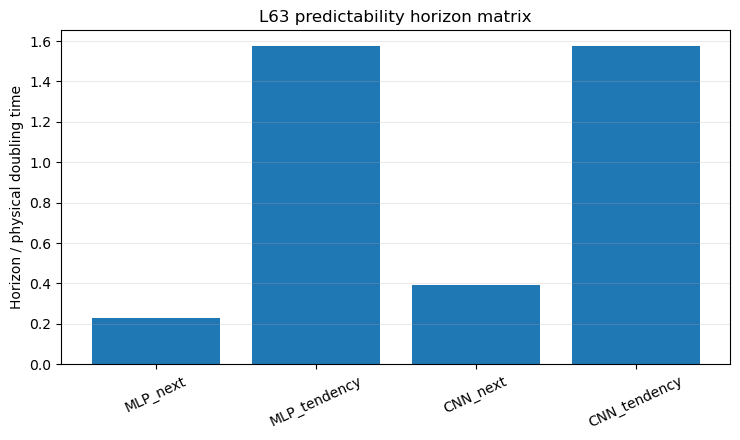

In [25]:
horizon = read_csv('13_prediction_horizon_100k.csv')
horizon['horizon_over_doubling_time'] = horizon['prediction_horizon'] / horizon['physical_doubling_time']
l63_horizon = horizon[horizon.system.eq('L63')][['label','prediction_horizon','physical_doubling_time','horizon_over_doubling_time']].copy()
l63_horizon.columns = ['Model','Horizon [model time]','Physical doubling time','Horizon / doubling time']
display(l63_horizon)

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.bar(l63_horizon['Model'], l63_horizon['Horizon / doubling time'])
ax.set_ylabel('Horizon / physical doubling time')
ax.set_title('L63 predictability horizon matrix')
ax.tick_params(axis='x', rotation=25)
ax.grid(axis='y', alpha=0.25)
fig.tight_layout()
fig.savefig(OUT_FIGS / 'l63_prediction_horizon_clean.png', dpi=180)
plt.show()


## 1.5 L63 Autoregressive Rollout Diagnostics

A model that fits one-step targets may still fail when its own outputs are recursively fed back as inputs. The rollout diagnostics test whether the learned emulator stays on a plausible Lorenz attractor.


,label,final_rmse,max_rmse,mean_rmse,prediction_horizon,horizon_step
0,MLP_next,173112.656250,173112.656250,24870.849609,0.25,25
1,MLP_tendency,5.308393,24.637249,10.456481,1.73,173
2,CNN_next,24.441315,46.798153,28.799788,0.43,43
3,CNN_tendency,20.679728,55.357262,13.472670,1.73,173


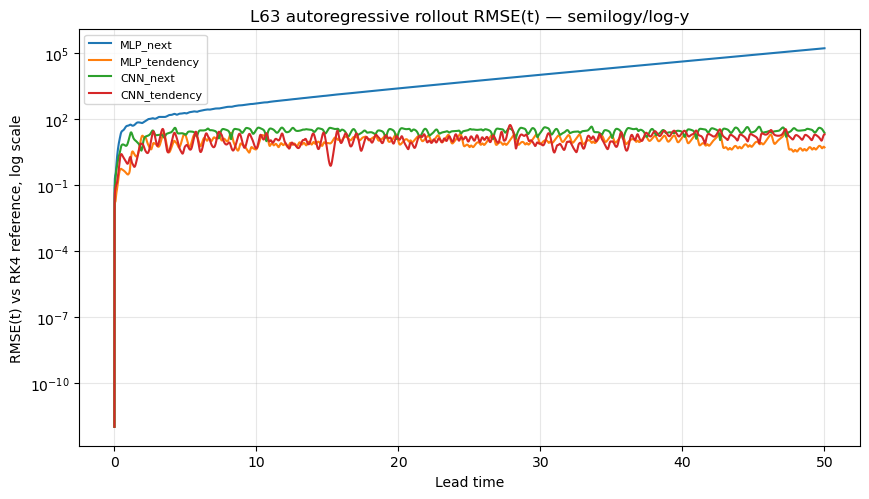

Saved explicit log-scale rollout figure: `figures/final_pretty/l63_rollout_rmse_logscale.png`

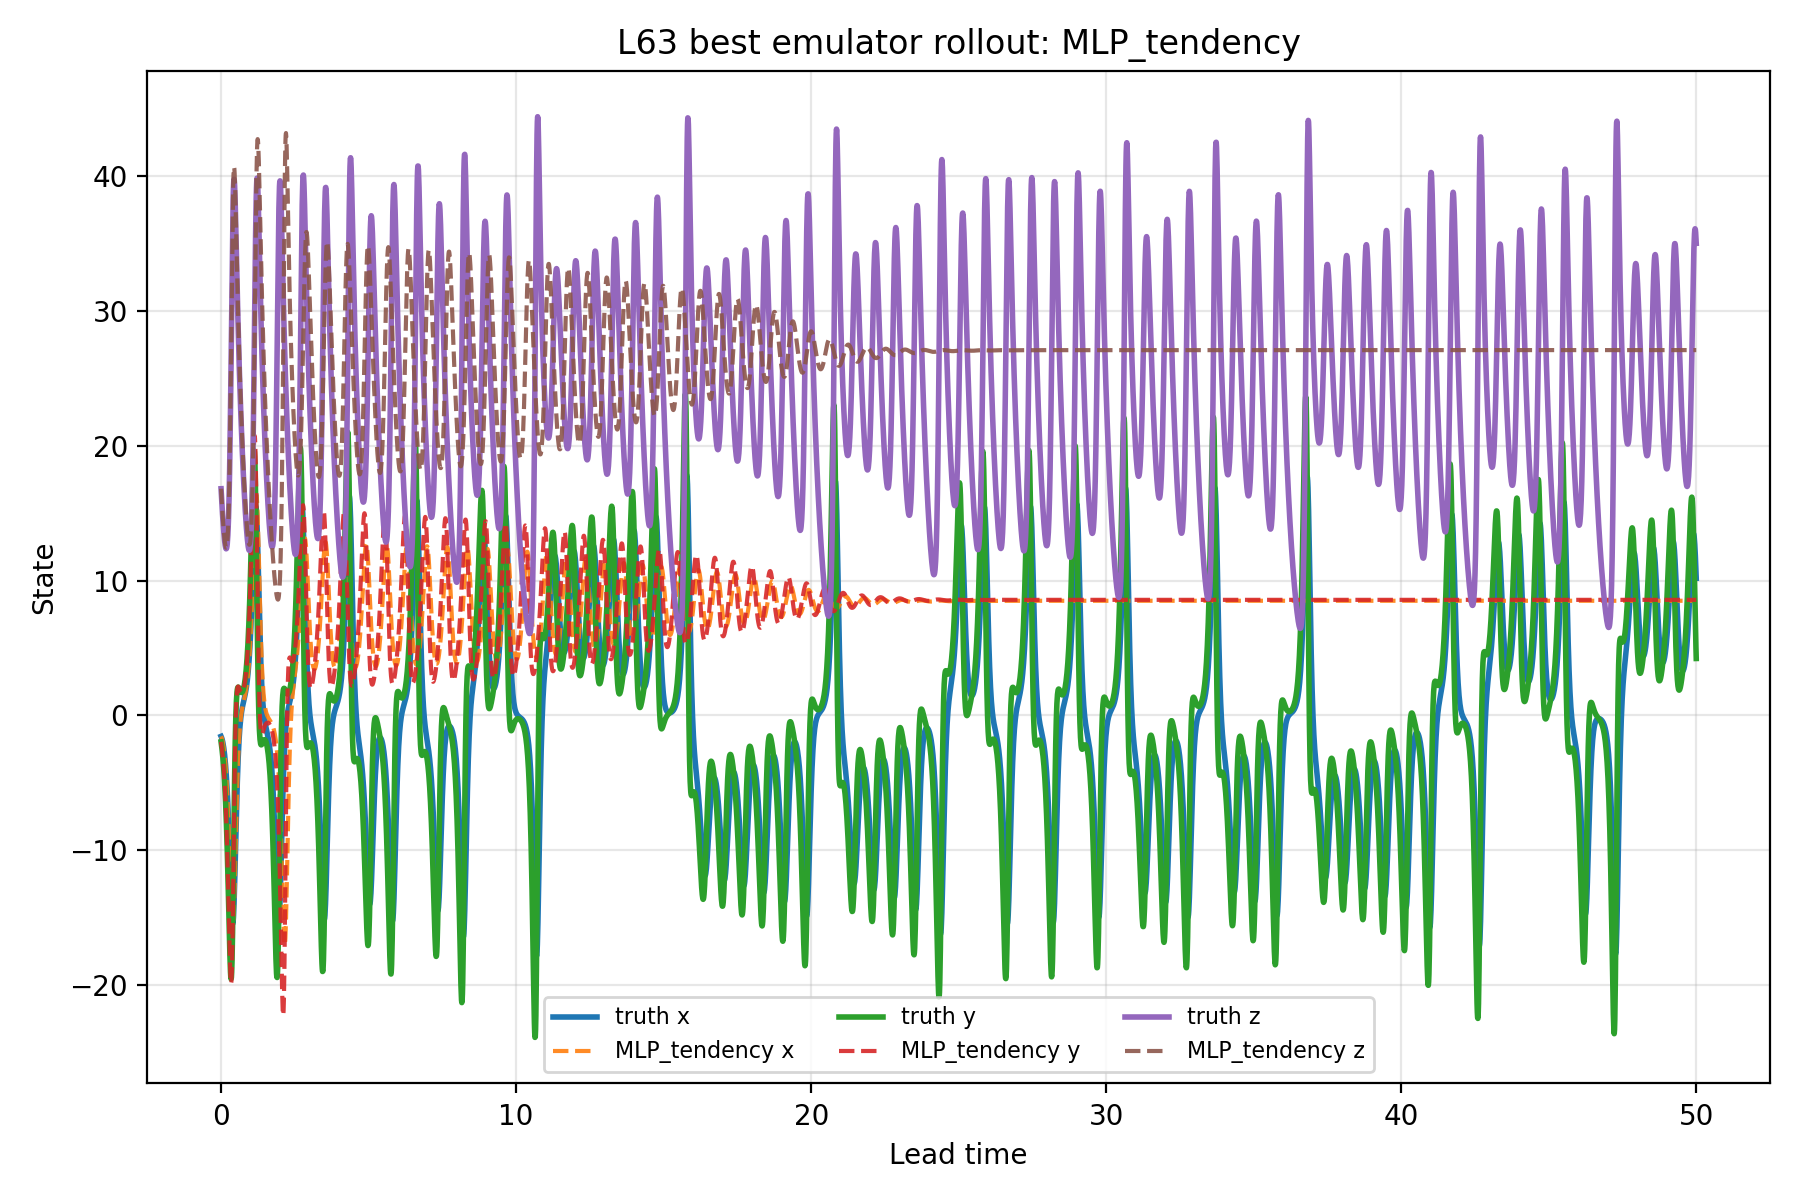

In [26]:
rollout = read_csv('13_rollout_100k_summary.csv')
l63_rollout = rollout[rollout.system.eq('L63')][['label','final_rmse','max_rmse','mean_rmse','prediction_horizon','horizon_step']]
display(l63_rollout)

# Autoregressive rollout RMSE(t) versus RK4 reference, explicitly plotted with semilogy/log-y.
plot_rollout_rmse_logscale('L63', width=850)

# Best-model trajectory comparison in state space/time series.
show_png('l63_100k_best_rollout_xyz.png', width=850)


## 1.6 L63 Leading Lyapunov Diagnostics

The leading Lyapunov exponent, lambda1, measures asymptotic exponential separation of nearby trajectories. The figure below avoids connecting unrelated model categories with a line: each emulator is shown as a bar and the physical reference is shown as a horizontal reference level.


,label,lambda1,reference_lambda,abs_error,n_steps
0,L63_physical_RK4,0.917680,0.91,0.007680,1000
2,L63_MLP_next,-0.367463,0.91,1.277463,1000
3,L63_MLP_tendency,0.514334,0.91,0.395666,1000
4,L63_CNN_next,0.218791,0.91,0.691209,1000
5,L63_CNN_tendency,1.563237,0.91,0.653237,1000


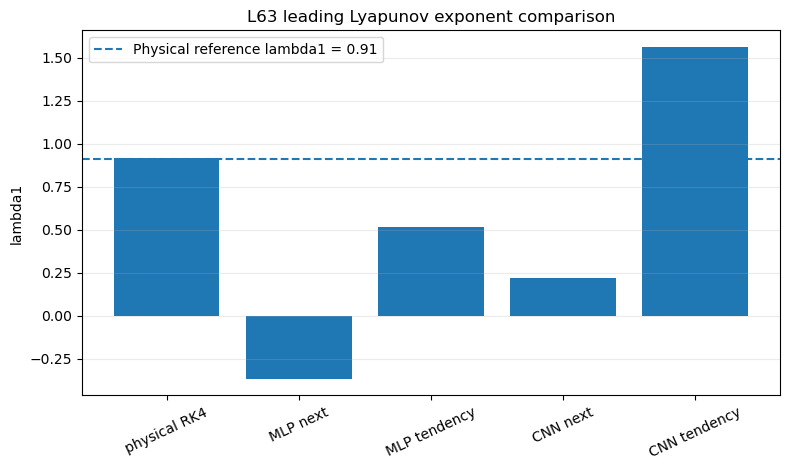

In [27]:
lyap = read_csv('14_lyapunov_100k_table.csv')
lyap['abs_error'] = (lyap['lambda1'] - lyap['reference_lambda']).abs()
l63_lyap = lyap[lyap.system.eq('L63')].copy()
display(l63_lyap[['label','lambda1','reference_lambda','abs_error','n_steps']])

plot_l63 = l63_lyap.copy()
plot_l63['plot_label'] = plot_l63['label'].str.replace('L63_', '', regex=False).str.replace('_', ' ')
ref = float(plot_l63['reference_lambda'].dropna().iloc[0])
fig, ax = plt.subplots(figsize=(8.0, 4.8))
ax.bar(plot_l63['plot_label'], plot_l63['lambda1'])
ax.axhline(ref, linestyle='--', linewidth=1.5, label=f'Physical reference lambda1 = {ref:.2f}')
ax.set_ylabel('lambda1')
ax.set_title('L63 leading Lyapunov exponent comparison')
ax.tick_params(axis='x', rotation=25)
ax.grid(axis='y', alpha=0.25)
ax.legend(loc='best')
fig.tight_layout()
fig.savefig(OUT_FIGS / 'l63_lyapunov_clean_bar.png', dpi=180)
plt.show()


## 1.7 L63 FTLE and Local Instability Diagnostics

Finite-time Lyapunov exponents (FTLEs) test whether the emulator reproduces local instability on the attractor. This is harder than matching one-step dynamics and is intentionally reported even when agreement is weak.


,model,mean,std,min,max,bias_vs_physical,mae_vs_physical,rmse_vs_physical,corr_vs_physical
0,physical,0.894520,0.937911,-0.727435,3.603590,0.000000,0.000000,0.000000,1.000000
1,mlp_tendency,2.309982,1.352497,-0.185411,7.740283,1.415461,1.570369,1.962070,0.340056
2,cnn_tendency,2.542388,1.488110,-0.425819,8.001098,1.647868,1.934932,2.386188,0.041458


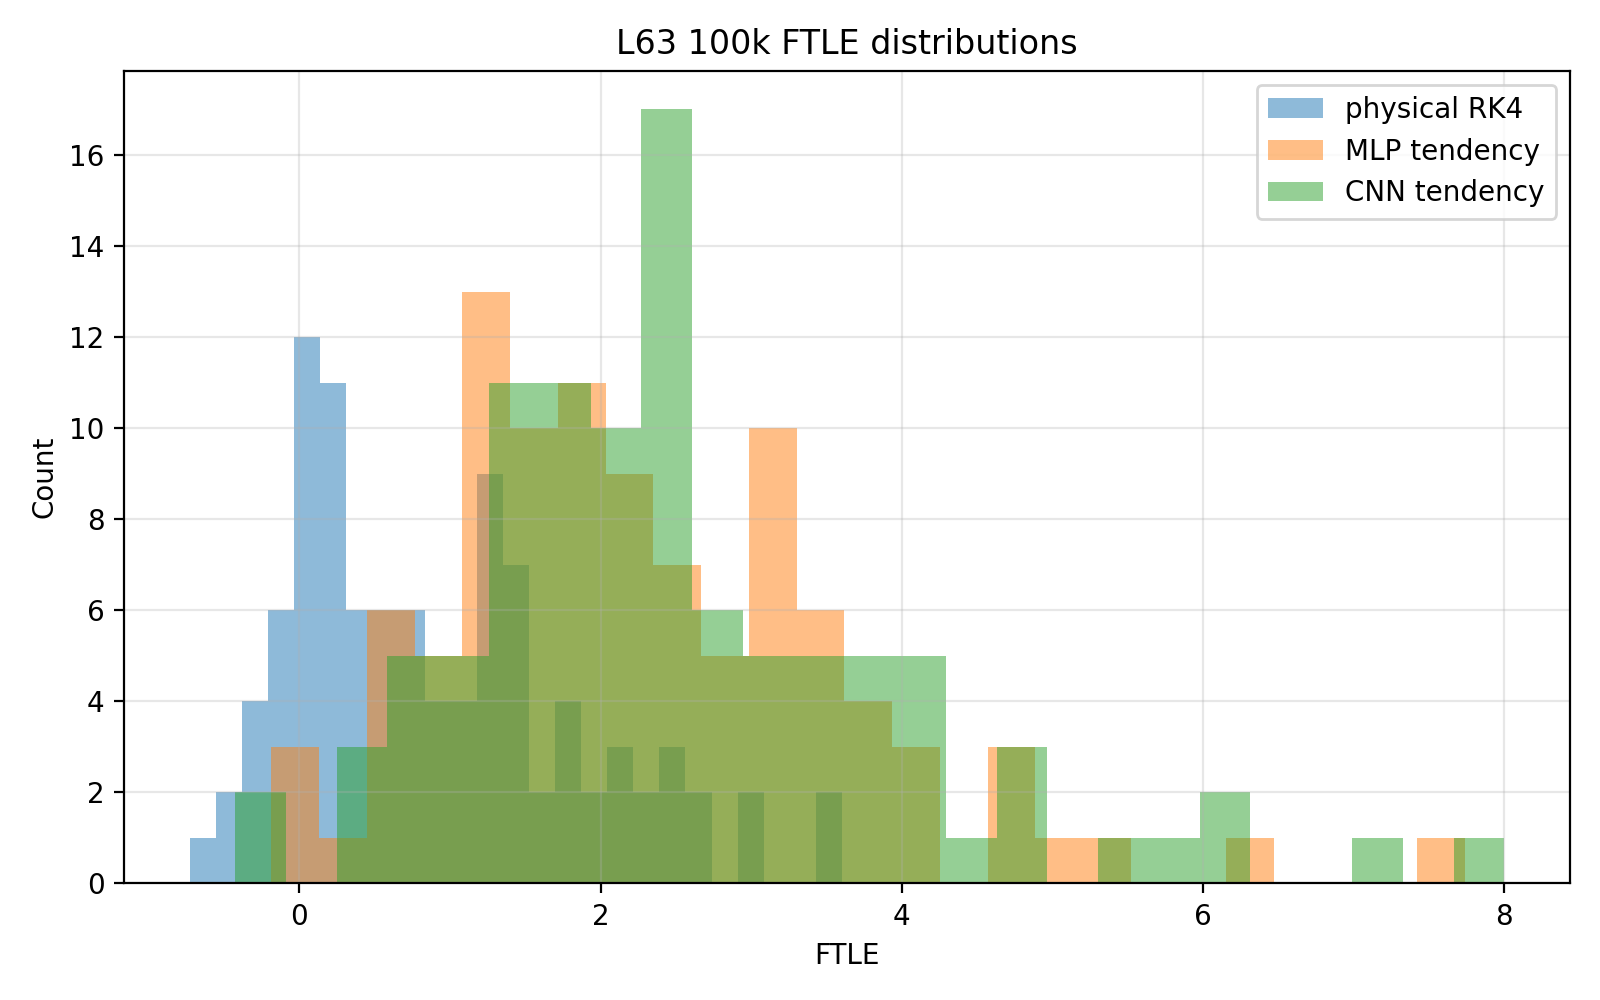

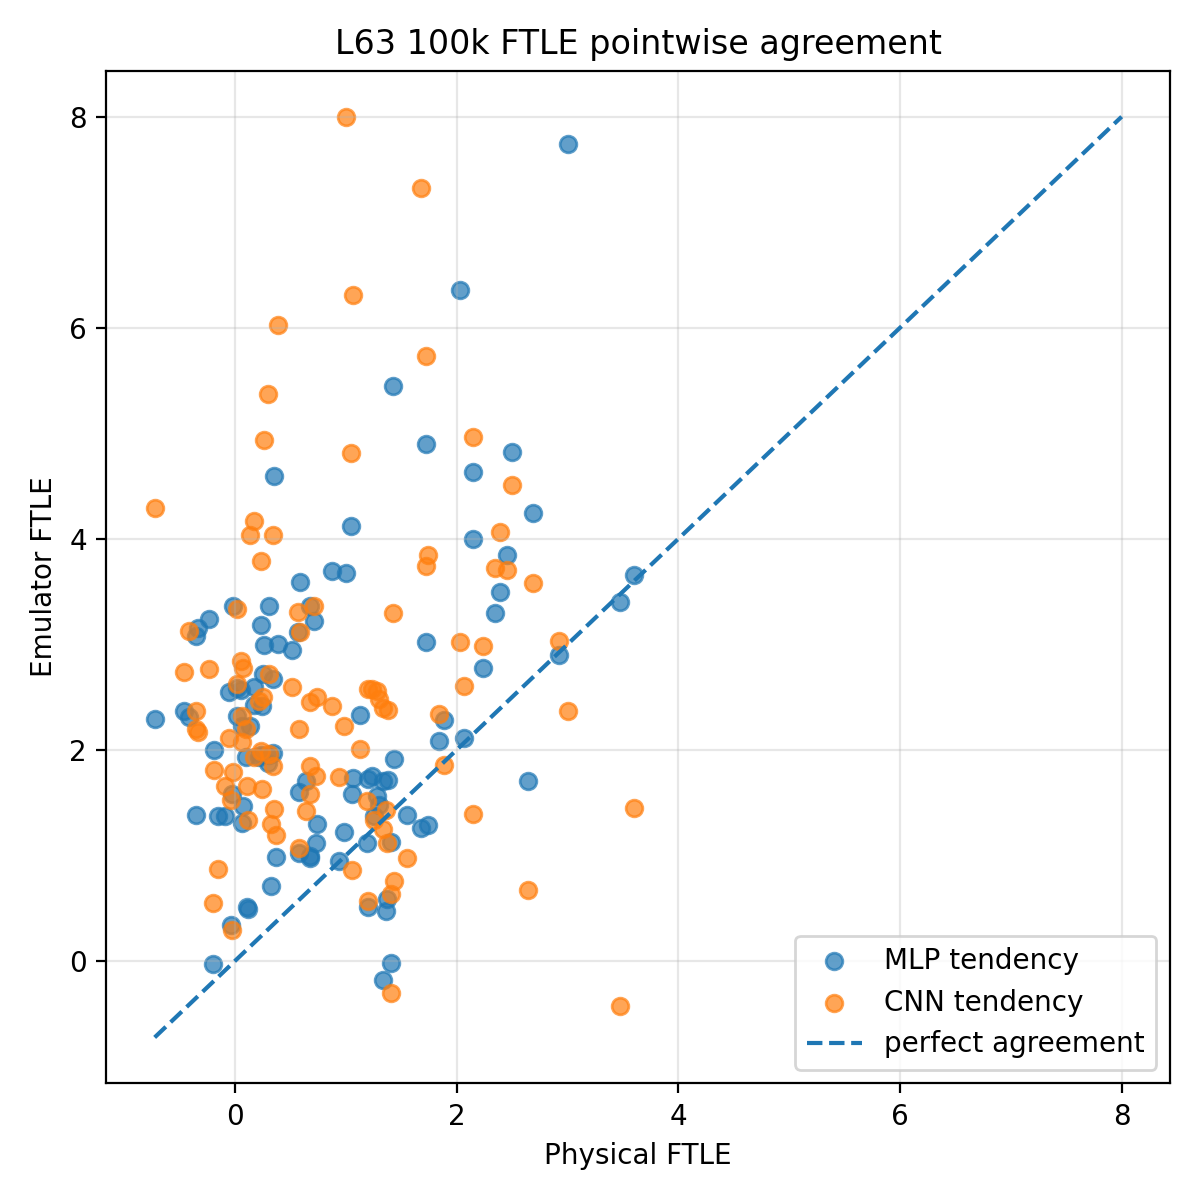

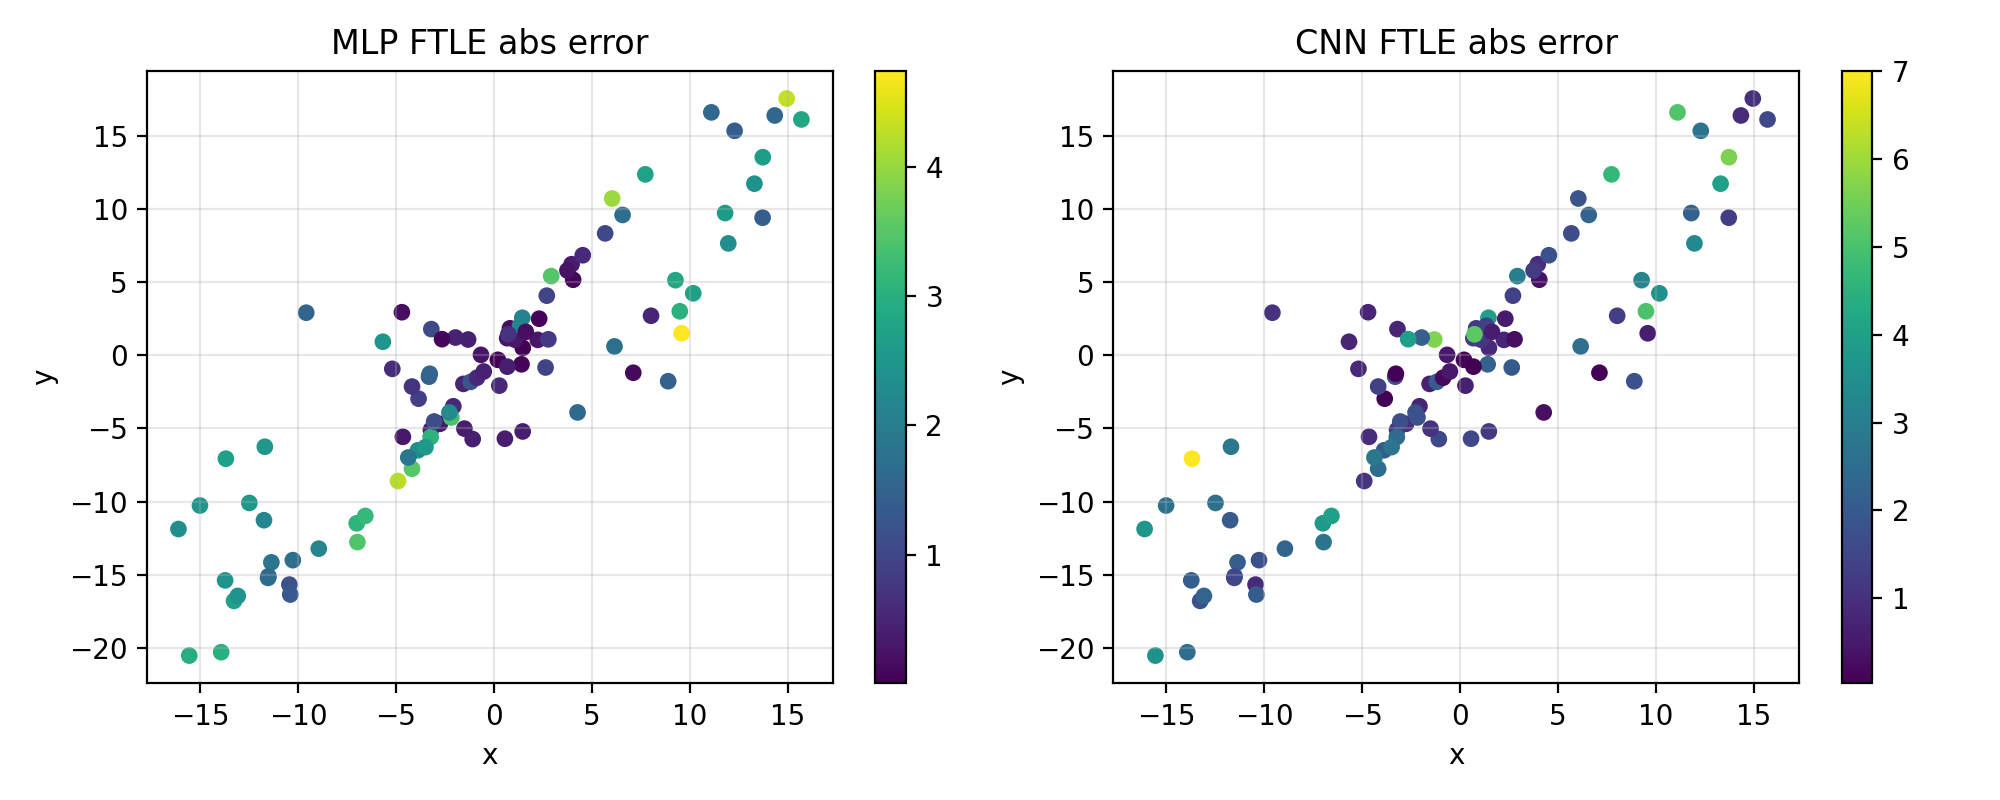

In [28]:
ftle = read_csv('14_ftle_l63_100k_summary.csv')
display(ftle)
show_png('14_ftle_l63_100k_hist.png', width=760)
show_png('14_ftle_l63_100k_scatter.png', width=760)
show_png('14_ftle_l63_100k_error_on_attractor.png', width=900)


## 1.8 L63 Spectral Diagnostics

Spectral diagnostics test whether the emulator preserves characteristic temporal variability, not only pointwise RMSE.


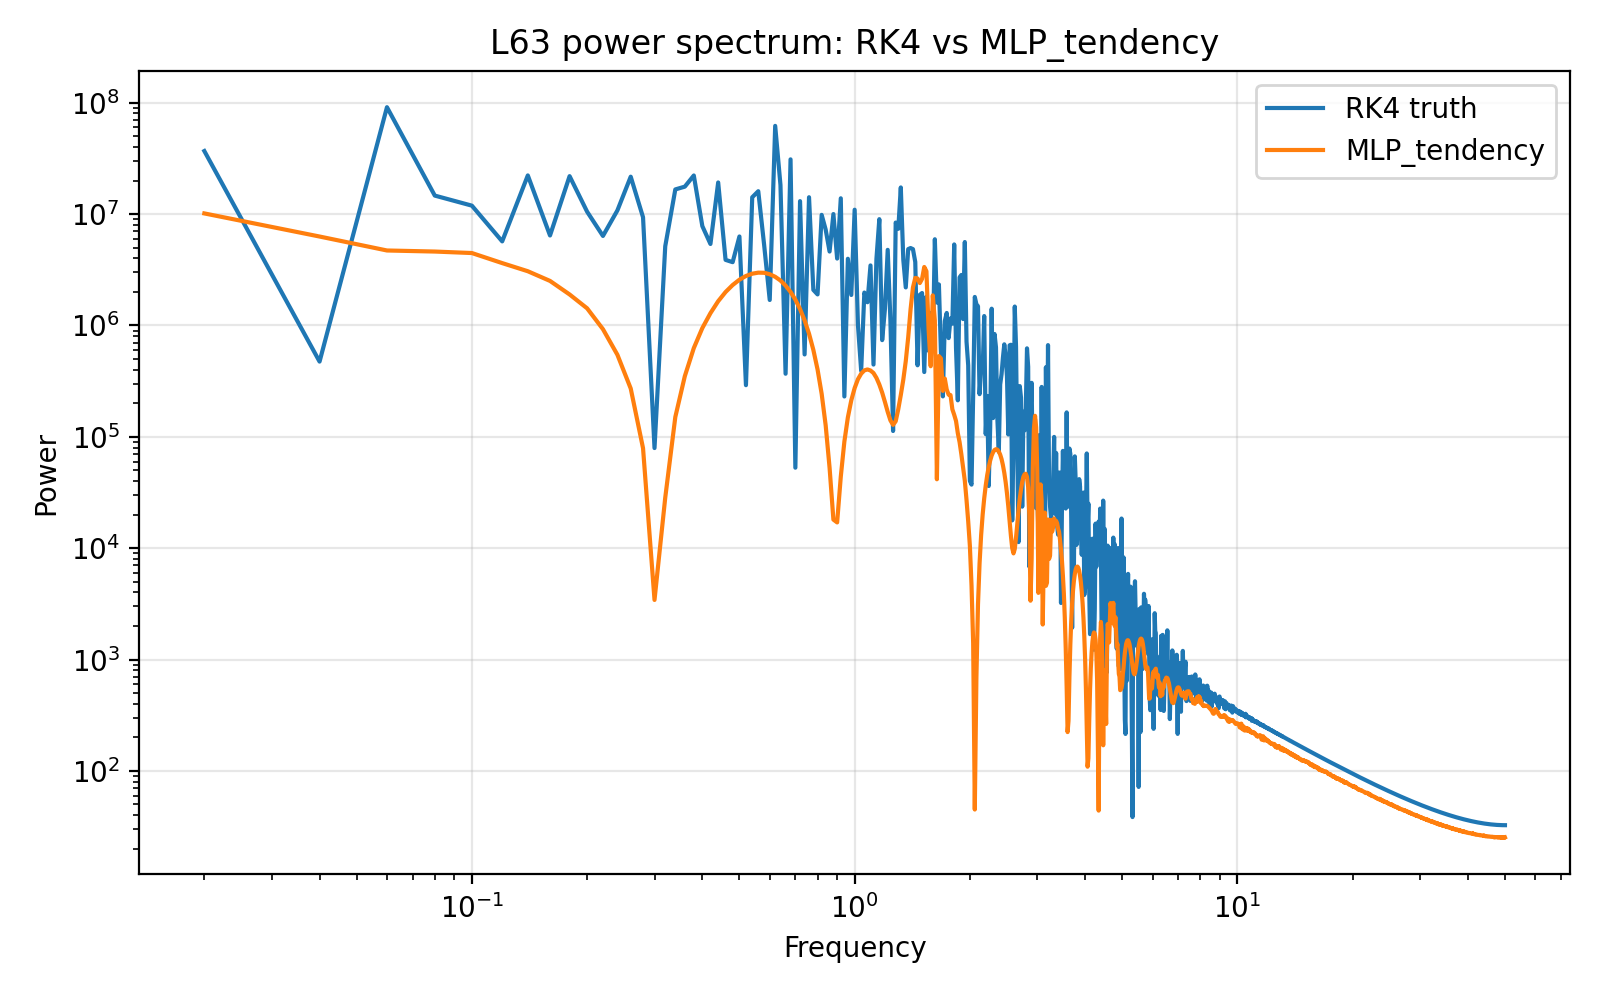

In [29]:
show_png('l63_100k_power_spectrum_best.png', width=850)


## 1.9 L63 Interpretation

For Lorenz-63, tendency learning improves dynamical plausibility relative to pure next-state learning. However, FTLE diagnostics show that local instability geometry remains difficult. This is an informative negative result: short-term prediction does not automatically imply faithful chaotic dynamics.


# Part II - Lorenz-96: spatially extended chaotic emulation

## 2.1 Mathematical model

The Lorenz-96 system is a spatially extended chaotic model on a periodic ring of \(N=40\) variables:

$$
\frac{dx_i}{dt} = (x_{i+1} - x_{i-2})x_{i-1} - x_i + F,
\qquad i = 0,\ldots,N-1.
$$

The cyclic indexing is the important physical structure. The forcing is \(F=8\).


## 2.2 L96 Dataset Verification Matrix


In [30]:
l96_matrix = pd.DataFrame([
    ['System', 'Lorenz-96'],
    ['Dimension', '40'],
    ['Forcing', 'F = 8'],
    ['Topology', 'periodic spatial ring'],
    ['Integrator', 'RK4 physical reference'],
    ['Time step', 'dt = 0.01'],
    ['Samples after spin-up', '100,000'],
    ['Splits', 'train / validation / test, non-overlapping'],
    ['Normalization', 'train statistics only'],
    ['Status', 'OK'],
], columns=['Quantity', 'Value'])
display(l96_matrix)


,Quantity,Value
0,System,Lorenz-96
1,Dimension,40
2,Forcing,F = 8
3,Topology,periodic spatial ring
4,Integrator,RK4 physical reference
5,Time step,dt = 0.01
6,Samples after spin-up,"100,000"
7,Splits,"train / validation / test, non-overlapping"
8,Normalization,train statistics only
9,Status,OK


## 2.3 L96 Emulator Architecture Matrix

The CNN architecture is physically meaningful for L96 because the state is a cyclic spatial ring. The tendency target is also physically motivated because the emulator learns a time derivative that is then integrated forward.


In [31]:
arch_l96 = pd.DataFrame([
    ['MLP next', 'x(t+dt)', 'Dense MLP', 'none'],
    ['MLP tendency', 'dx/dt', 'Dense MLP', 'tendency integration'],
    ['CNN next', 'x(t+dt)', '1-D CNN', 'periodic ring'],
    ['CNN tendency', 'dx/dt', '1-D CNN', 'periodic ring + tendency'],
], columns=['Model', 'Target', 'Architecture', 'Physical bias'])
display(arch_l96)

display(train[train.system.eq('L96')][['case_name','architecture','target','n_params','test_mse','test_mae','as_next_mse','as_next_mae']])


,Model,Target,Architecture,Physical bias
0,MLP next,x(t+dt),Dense MLP,none
1,MLP tendency,dx/dt,Dense MLP,tendency integration
2,CNN next,x(t+dt),1-D CNN,periodic ring
3,CNN tendency,dx/dt,1-D CNN,periodic ring + tendency


,case_name,architecture,target,n_params,test_mse,test_mae,as_next_mse,as_next_mae
4,l96_mlp_next_100k,MLP,next,152360,0.043634,0.158718,NaN,NaN
5,l96_mlp_tendency_100k,MLP,tendency,152360,16.533537,3.136500,0.001653,0.031365
6,l96_cnn_next_100k,CNN,next,41537,0.000559,0.018545,NaN,NaN
7,l96_cnn_tendency_100k,CNN,tendency,41537,0.151271,0.289847,0.000015,0.002898


## 2.4 L96 Predictability Horizon Matrix

The strongest L96 model is expected to remain useful for several physical doubling times, not merely for a few one-step predictions.


,Model,Horizon [model time],Physical doubling time,Horizon / doubling time
4,MLP_next,0.11,0.595238,0.1848
5,MLP_tendency,0.71,0.595238,1.1928
6,CNN_next,0.64,0.595238,1.0752
7,CNN_tendency,2.28,0.595238,3.8304


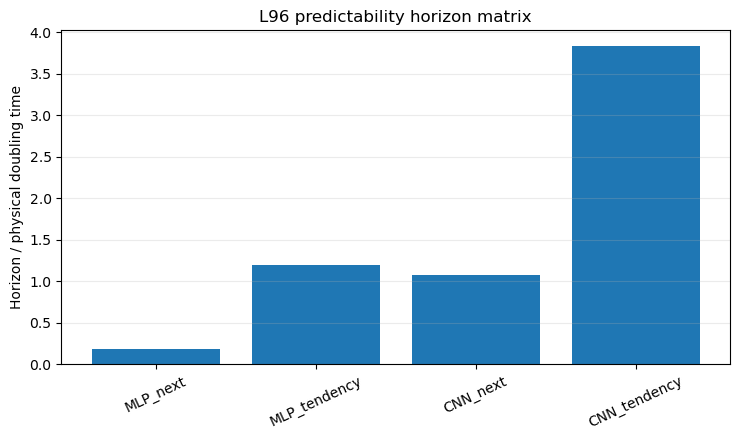

In [32]:
l96_horizon = horizon[horizon.system.eq('L96')][['label','prediction_horizon','physical_doubling_time','horizon_over_doubling_time']].copy()
l96_horizon.columns = ['Model','Horizon [model time]','Physical doubling time','Horizon / doubling time']
display(l96_horizon)

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.bar(l96_horizon['Model'], l96_horizon['Horizon / doubling time'])
ax.set_ylabel('Horizon / physical doubling time')
ax.set_title('L96 predictability horizon matrix')
ax.tick_params(axis='x', rotation=25)
ax.grid(axis='y', alpha=0.25)
fig.tight_layout()
fig.savefig(OUT_FIGS / 'l96_prediction_horizon_clean.png', dpi=180)
plt.show()


## 2.5 L96 Autoregressive Rollout Diagnostics

The L96 rollout is the central stress test. The direct next-state MLP is a clear failure case: it can fit one-step targets but becomes unstable under autoregressive iteration. The CNN tendency model provides the strongest long-horizon compromise.


,label,final_rmse,max_rmse,mean_rmse,prediction_horizon,horizon_step
4,MLP_next,6.360929e+12,6.360929e+12,2.351306e+11,0.11,11
5,MLP_tendency,4.983687e+00,7.008903e+00,5.154584e+00,0.71,71
6,CNN_next,4.783895e+00,6.040559e+00,4.669500e+00,0.64,64
7,CNN_tendency,5.540106e+00,6.282534e+00,4.847412e+00,2.28,228


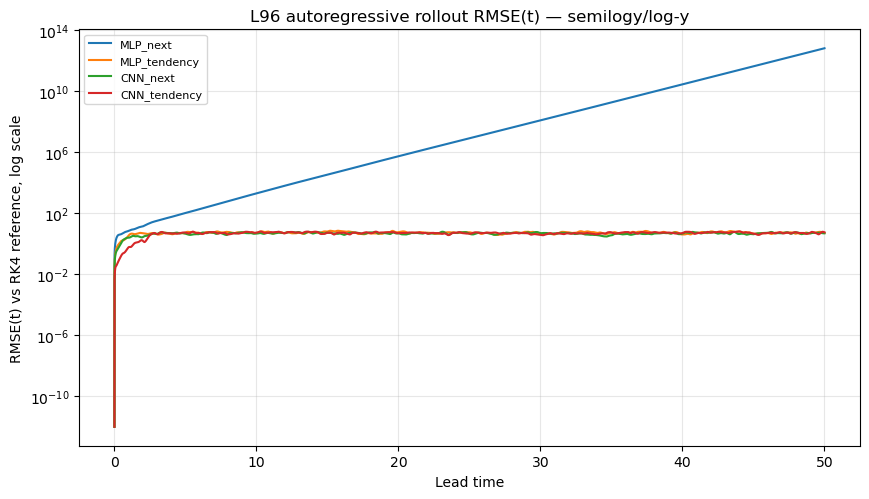

Saved explicit log-scale rollout figure: `figures/final_pretty/l96_rollout_rmse_logscale.png`

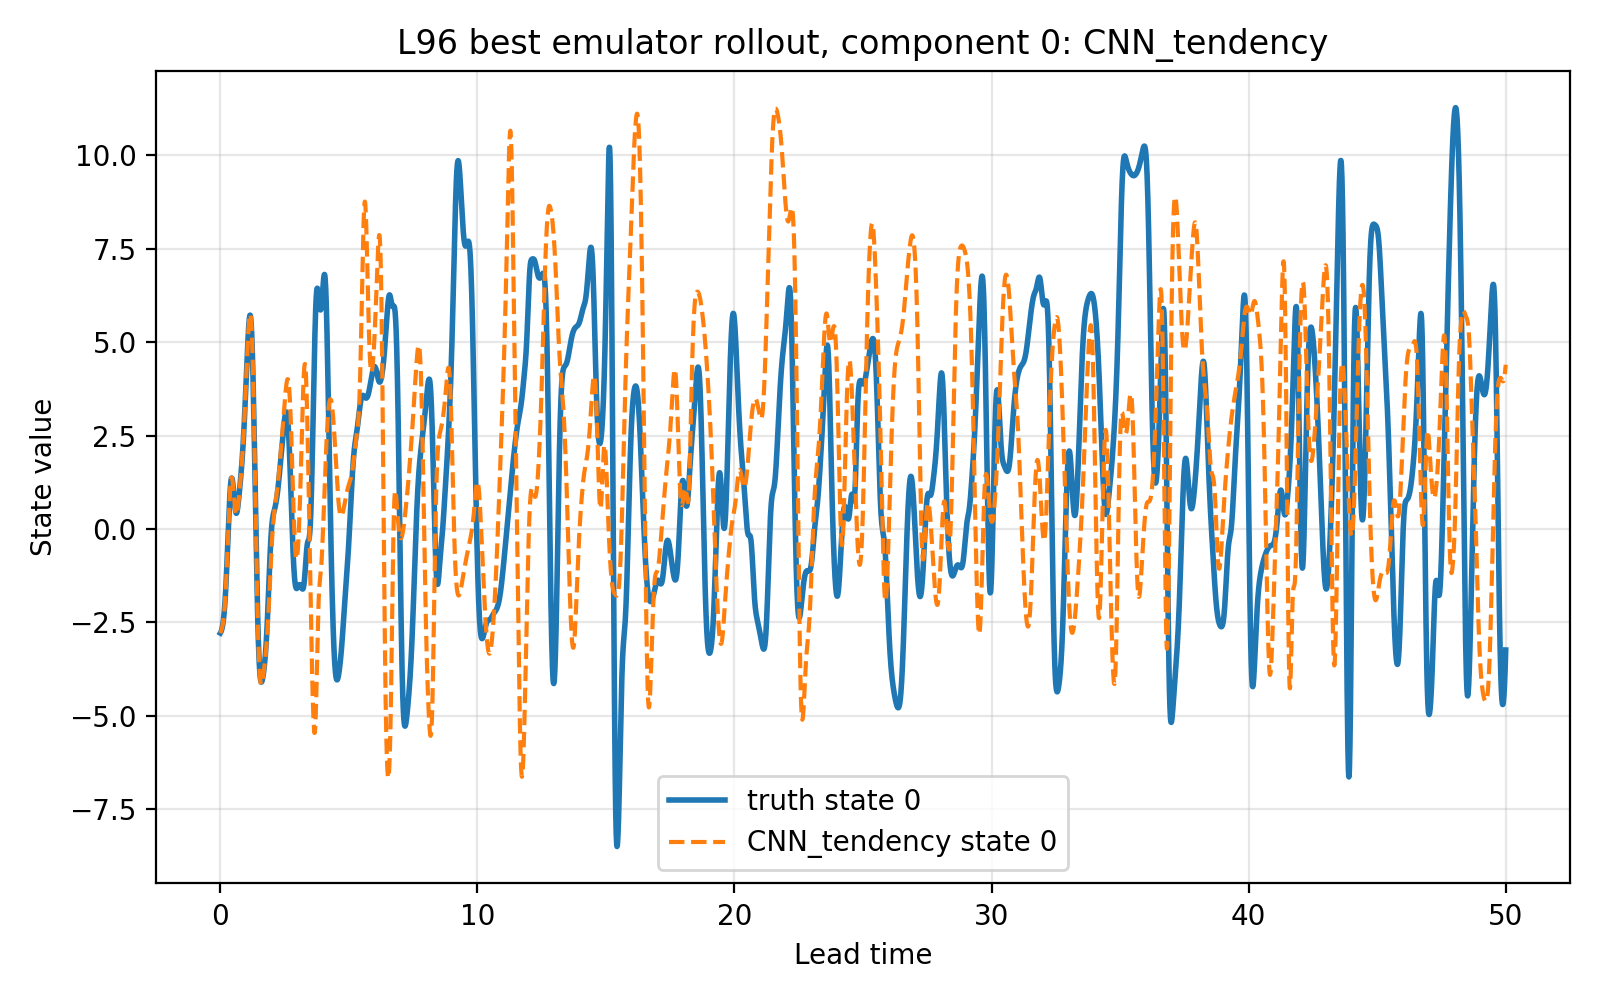

In [33]:
l96_rollout = rollout[rollout.system.eq('L96')][['label','final_rmse','max_rmse','mean_rmse','prediction_horizon','horizon_step']]
display(l96_rollout)

# Autoregressive rollout RMSE(t) versus RK4 reference, explicitly plotted with semilogy/log-y.
plot_rollout_rmse_logscale('L96', width=850)

# Best-model trajectory comparison for component 0.
show_png('l96_100k_best_rollout_state0.png', width=850)


## 2.6 L96 Leading Lyapunov Diagnostics

The L96 Lyapunov comparison is shown separately from L63. This prevents a misleading line from connecting physically unrelated categories. The reference value is shown as a horizontal level at lambda1 = 1.68.


,label,lambda1,reference_lambda,abs_error,n_steps
1,L96_reference,1.680000,1.68,0.000000,0
6,L96_MLP_next,0.524772,1.68,1.155228,500
7,L96_MLP_tendency,1.792867,1.68,0.112867,500
8,L96_CNN_next,1.717282,1.68,0.037282,500
9,L96_CNN_tendency,2.032712,1.68,0.352712,500


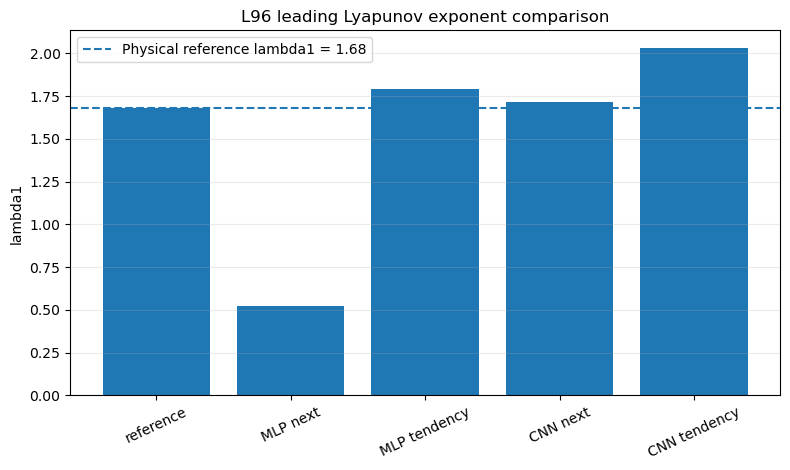

In [34]:
l96_lyap = lyap[lyap.system.eq('L96')].copy()
display(l96_lyap[['label','lambda1','reference_lambda','abs_error','n_steps']])

plot_l96 = l96_lyap.copy()
plot_l96['plot_label'] = plot_l96['label'].str.replace('L96_', '', regex=False).str.replace('_', ' ')
ref = float(plot_l96['reference_lambda'].dropna().iloc[0])
fig, ax = plt.subplots(figsize=(8.0, 4.8))
ax.bar(plot_l96['plot_label'], plot_l96['lambda1'])
ax.axhline(ref, linestyle='--', linewidth=1.5, label=f'Physical reference lambda1 = {ref:.2f}')
ax.set_ylabel('lambda1')
ax.set_title('L96 leading Lyapunov exponent comparison')
ax.tick_params(axis='x', rotation=25)
ax.grid(axis='y', alpha=0.25)
ax.legend(loc='best')
fig.tight_layout()
fig.savefig(OUT_FIGS / 'l96_lyapunov_clean_bar.png', dpi=180)
plt.show()


## 2.7 L96 Spectral and Spatial Diagnostics

The spacetime and spectral diagnostics test whether the emulator preserves structure beyond short-term forecast accuracy.


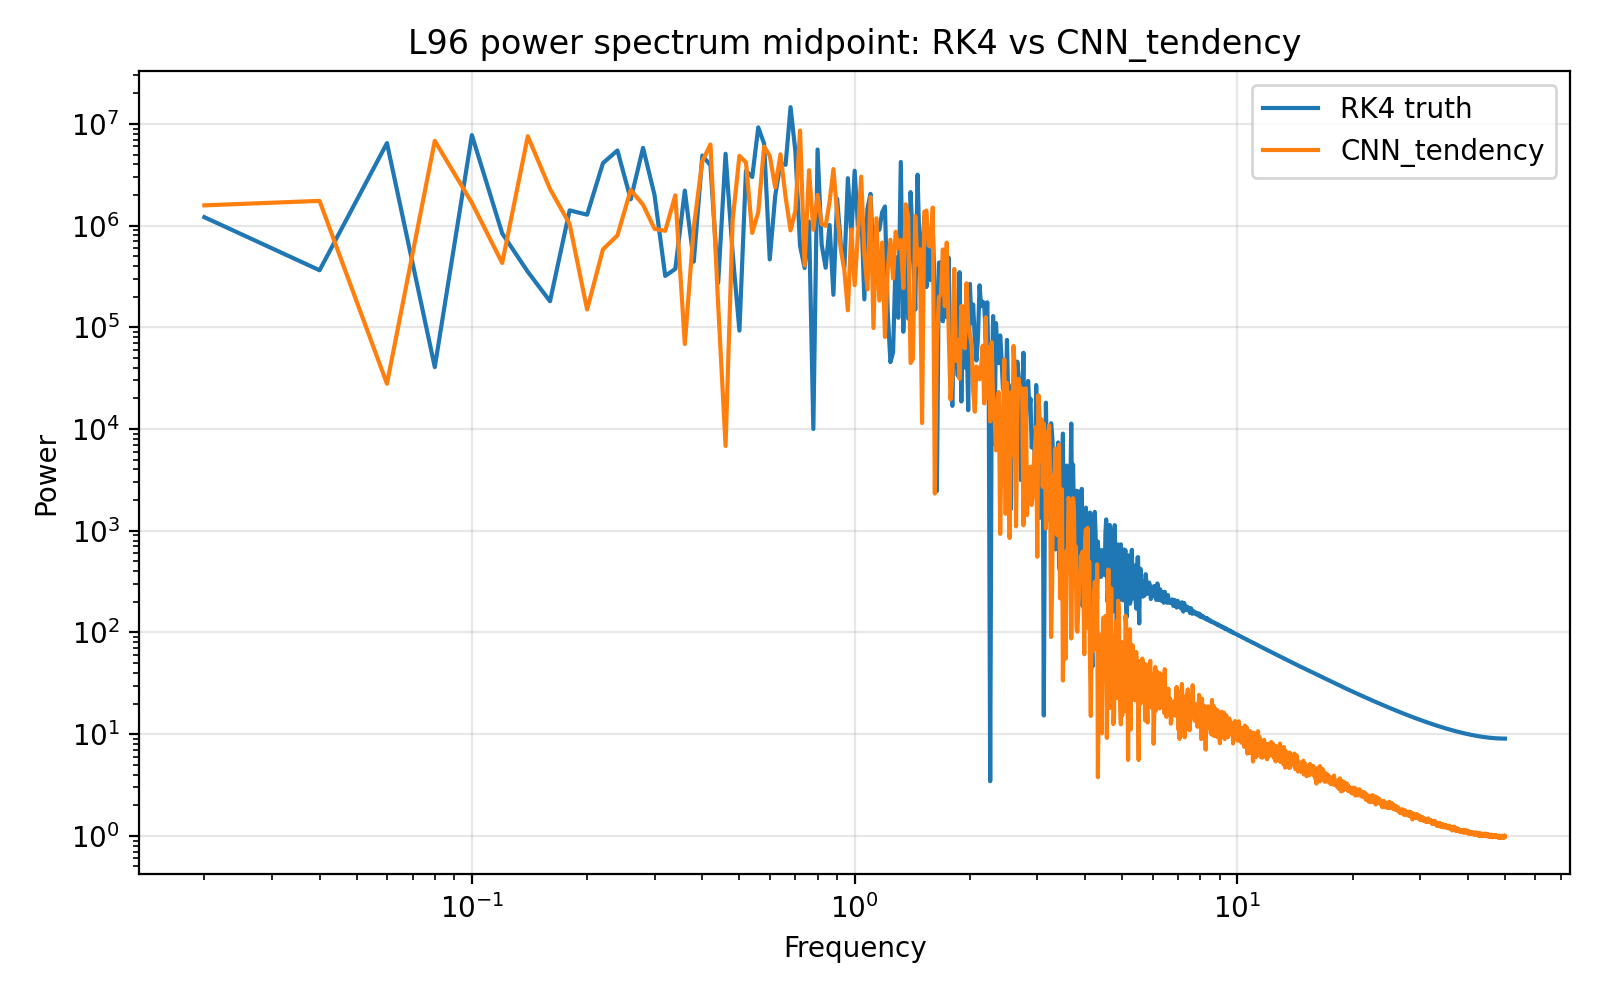

In [35]:
show_png('l96_100k_power_spectrum_best.png', width=850)


## 2.8 L96 Interpretation

For Lorenz-96, the best overall result is obtained by combining tendency learning with a CNN architecture matched to the periodic ring topology. The result supports the central Project D hypothesis: architecture and target choice matter for chaotic emulation.


# Part III - Cross-system synthesis

## 3.1 Final Model Scorecard

The scorecard below combines one-step skill, autoregressive rollout, Lyapunov fidelity, and local instability diagnostics. It is intended as a scientific interpretation table rather than a single scalar ranking.


In [36]:
scorecard = pd.DataFrame([
    ['L63', 'MLP next', 'short-horizon baseline', 'weak', 'poor', 'baseline'],
    ['L63', 'MLP tendency', 'improved', 'moderate/good', 'limited FTLE agreement', 'useful'],
    ['L63', 'CNN next', 'auxiliary baseline', 'mixed', 'limited FTLE agreement', 'secondary'],
    ['L63', 'CNN tendency', 'auxiliary tendency baseline', 'mixed', 'limited FTLE agreement', 'secondary'],
    ['L96', 'MLP next', 'one-step baseline', 'poor / unstable', 'poor lambda1 fidelity', 'weak'],
    ['L96', 'MLP tendency', 'improved', 'moderate/good', 'closer lambda1 scale', 'useful'],
    ['L96', 'CNN next', 'strong one-step and rollout', 'good', 'close but slightly overactive', 'strong'],
    ['L96', 'CNN tendency', 'best horizon', 'best compromise', 'good lambda1 scale', 'best'],
], columns=['System','Model','Short-term behavior','Rollout behavior','Chaos diagnostic behavior','Overall'])
display(scorecard)


,System,Model,Short-term behavior,Rollout behavior,Chaos diagnostic behavior,Overall
0,L63,MLP next,short-horizon baseline,weak,poor,baseline
1,L63,MLP tendency,improved,moderate/good,limited FTLE agreement,useful
2,L63,CNN next,auxiliary baseline,mixed,limited FTLE agreement,secondary
3,L63,CNN tendency,auxiliary tendency baseline,mixed,limited FTLE agreement,secondary
4,L96,MLP next,one-step baseline,poor / unstable,poor lambda1 fidelity,weak
5,L96,MLP tendency,improved,moderate/good,closer lambda1 scale,useful
6,L96,CNN next,strong one-step and rollout,good,close but slightly overactive,strong
7,L96,CNN tendency,best horizon,best compromise,good lambda1 scale,best


## 3.2 Main conclusions

1. **Tendency learning is better conditioned than direct next-state prediction.**  
   This is visible in both Lorenz-63 and Lorenz-96, especially in autoregressive rollout.

2. **The L96 periodic CNN bias is important.**  
   Lorenz-96 lives on a cyclic spatial ring, so a CNN with the right topology is more physically aligned than a dense MLP.

3. **One-step loss is not a sufficient metric.**  
   Several models have reasonable one-step behavior but fail under rollout or Lyapunov/FTLE diagnostics.

4. **Negative results are scientifically useful.**  
   FTLE mismatch and unstable rollouts show exactly where supervised emulators fail to reproduce chaotic dynamics.

5. **Best L96 model:** CNN tendency.  
   It gives the strongest compromise between forecast horizon, rollout stability, and dynamical consistency.


## 3.3 Limitations

- The models are trained with supervised one-step losses only.
- No explicit multi-step, invariant-measure, or physics-informed loss is used.
- FTLE diagnostics are demanding and reveal local-instability mismatches even for otherwise useful models.
- Lorenz-96 uses a 40-variable periodic ring; conclusions about CNN inductive bias are specific to spatially structured systems.


## 3.4 Files used by this notebook

Key report files:

- `reports/12_train_100k_models_summary_clean.csv`
- `reports/13_rollout_100k_summary.csv`
- `reports/13_prediction_horizon_100k.csv`
- `reports/14_lyapunov_100k_table.csv`
- `reports/14_ftle_l63_100k_summary.csv`

Key figure files:

- `figures/l63_100k_rollout_rmse_all.png`
- `figures/l96_100k_rollout_rmse_all.png`
- `figures/final_pretty/l63_rollout_rmse_logscale.png`
- `figures/final_pretty/l96_rollout_rmse_logscale.png`
- `figures/l63_100k_best_rollout_xyz.png`
- `figures/l96_100k_best_rollout_state0.png`
- `figures/14_ftle_l63_100k_hist.png`
- `figures/14_ftle_l63_100k_scatter.png`
- `figures/l63_100k_power_spectrum_best.png`
- `figures/l96_100k_power_spectrum_best.png`

Newly generated clean figures are saved under:

- `figures/final_pretty/`


## 3.5 Final export commands

After running all cells, the notebook can be exported to HTML from a terminal.

If the notebook is in the same directory as the project zip:

```bash
jupyter nbconvert --to html lorenz96ReportV4.ipynb
```

The recommended final submission/archive contains:

```text
README_REPRODUCIBILITY.md
lorenz96ReportV4.ipynb
lorenz96_project_final_package/reports/
lorenz96_project_final_package/figures/
lorenz96_project_final_package/collected_runs/lorenz96_results_<run-id>.zip
lorenz96_results_<user>_fullshare.tar.gz
```